# PROCESSO EM MENOS ETAPAS

## 1. Preparação da série

In [91]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

from validacao_carga_inmet import carregar_e_validar_diretorio

resultado_carga = carregar_e_validar_diretorio(
    pasta=".",
    padrao="INMET*.CSV",
    wmo_esperado="A707",
    limite_ausencia_alvo=0.20,
    excluir_anos_incompletos=True
)

df = resultado_carga["dados"]
relatorio_arquivos = resultado_carga["relatorio_arquivos"]
relatorio_colunas = resultado_carga["relatorio_colunas"]

COLUNA_ALVO = "umidade_max_hora_anterior_pct"

df = df.drop(columns=["Unnamed: 19"], errors="ignore")

df["datetime"] = pd.to_datetime(
    df["data"].astype(str)
    + " "
    + df["hora_utc"].astype(str).str.replace(
        " UTC", "", regex=False
    ),
    format="%Y/%m/%d %H%M",
    errors="coerce",
    utc=True
)

df[COLUNA_ALVO] = pd.to_numeric(
    df[COLUNA_ALVO],
    errors="coerce"
)

df = (
    df.sort_values("datetime")
      .drop_duplicates(subset="datetime")
      .reset_index(drop=True)
)

# Mantém a frequência horária
serie_bruta = df[COLUNA_ALVO].copy()

# Para o relatório, informe que os valores ausentes foram preenchidos pelo último valor observado, preservando a causalidade temporal.
serie_bruta = serie_bruta.ffill()

if serie_bruta.isna().any():
    mediana_inicial = serie_bruta.dropna().iloc[:24].median()
    serie_bruta = serie_bruta.fillna(mediana_inicial)

df[COLUNA_ALVO] = serie_bruta

serie = df[COLUNA_ALVO].to_numpy(dtype=np.float32)
datas = df["datetime"].to_numpy()

n_total = len(serie)

fim_treino = int(n_total * 0.70)
fim_validacao = int(n_total * 0.85)

serie_treino = serie[:fim_treino]
serie_validacao = serie[fim_treino:fim_validacao]
serie_teste = serie[fim_validacao:]

datas_treino = datas[:fim_treino]
datas_validacao = datas[fim_treino:fim_validacao]
datas_teste = datas[fim_validacao:]

print(f"Total: {n_total}")
print(f"Treino: {len(serie_treino)}")
print(f"Validação: {len(serie_validacao)}")
print(f"Teste final: {len(serie_teste)}")

print(f"Treino: {datas_treino[0]} até {datas_treino[-1]}")
print(
    f"Validação: {datas_validacao[0]} até {datas_validacao[-1]}"
)
print(f"Teste: {datas_teste[0]} até {datas_teste[-1]}")

media_treino = serie_treino.mean()
desvio_treino = serie_treino.std()

serie_normalizada = (
    (serie - media_treino) / desvio_treino
).astype(np.float32)

Total: 8760
Treino: 6132
Validação: 1314
Teste final: 1314
Treino: 2025-01-01 00:00:00+00:00 até 2025-09-13 11:00:00+00:00
Validação: 2025-09-13 12:00:00+00:00 até 2025-11-07 05:00:00+00:00
Teste: 2025-11-07 06:00:00+00:00 até 2025-12-31 23:00:00+00:00


In [92]:
print(relatorio_arquivos.to_string(index=False))

assert not df.empty
assert df["datetime"].is_monotonic_increasing
assert not df["datetime"].duplicated().any()
assert COLUNA_ALVO in df.columns


                                                         arquivo  wmo             estacao     latitude    longitude altitude  n_linhas  n_colunas_originais                    inicio                       fim  timestamps_invalidos  timestamps_duplicados  lacunas_horarias  ausencia_alvo_pct  maior_bloco_ausente_alvo_horas colunas_desconhecidas colunas_faltantes colunas_canonicas_duplicadas  violacoes_faixa_total  erro_estrutural  aprovado_modelagem
INMET_SE_SP_A707_PRESIDENTE PRUDENTE_01-01-2025_A_31-12-2025.CSV A707 PRESIDENTE PRUDENTE -22,11999999 -51,40861111   431,92      8760                   19 2025-01-01 00:00:00+00:00 2025-12-31 23:00:00+00:00                     0                      0                 0           0.513699                               8                                                                                           0            False                True


In [2]:
# ÍNDICE DA VALIDAÇÃO

indice_inicio_validacao = fim_treino
indice_fim_validacao = fim_validacao

# ÍNDICE DO TESTE

indice_inicio_teste = fim_validacao
indice_fim_teste = len(serie)

# 2. Criação das janelas

Vamos usar as últimas 24 horas para prever a hora seguinte:

In [3]:
tau = 24

def criar_janelas(serie, tau):
    X = []
    y = []

    for i in range(tau, len(serie)):
        X.append(serie[i - tau:i])
        y.append(serie[i])

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32).reshape(-1, 1)
    )

X, y = criar_janelas(
    serie_normalizada,
    tau
)

datas_y = datas[tau:]

corte_treino_janelas = fim_treino - tau
corte_validacao_janelas = fim_validacao - tau

X_train = X[:corte_treino_janelas]
y_train = y[:corte_treino_janelas]

X_val = X[
    corte_treino_janelas:corte_validacao_janelas
]
y_val = y[
    corte_treino_janelas:corte_validacao_janelas
]

X_test = X[corte_validacao_janelas:]
y_test = y[corte_validacao_janelas:]

datas_val = datas_y[
    corte_treino_janelas:corte_validacao_janelas
]

datas_test = datas_y[
    corte_validacao_janelas:
]

print(f"Treino: {X_train.shape}, {y_train.shape}")
print(f"Validação: {X_val.shape}, {y_val.shape}")
print(f"Teste: {X_test.shape}, {y_test.shape}")

Treino: (6108, 24), (6108, 1)
Validação: (1314, 24), (1314, 1)
Teste: (1314, 24), (1314, 1)


# 3. Treinamento e/ou carregamento do modelo

## 3.1. Carregamento das variáveis

In [4]:
SEMENTES = [10, 20, 30, 40, 50]

In [5]:
class GRURegressor(nn.Module):
    def __init__(self, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()

        self.gru = nn.GRU(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.output = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Entrada original: (batch_size, tau)
        # Entrada da GRU: (batch_size, tau, 1)
        x = x.unsqueeze(-1)
        output, _ = self.gru(x)
        return self.output(output[:, -1, :])

In [ ]:
def criar_modelo_linear(tau):
    return nn.Linear(tau, 1)


def criar_modelo_gru(
    hidden_size=64,
    num_layers=2,
    dropout=0.2
):
    return GRURegressor(
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout
    )

In [13]:
modelos_treinados = {
    "Linear": [],
    "GRU": []
}

historicos = {
    "Linear": [],
    "GRU": []
}

## 3.2. Treinamento inicial

In [14]:
# Preparação dos tensores e DataLoader

def criar_dataloader(
    X,
    y,
    batch_size=32,
    shuffle=False
):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        pin_memory=torch.cuda.is_available()
    )

    return dataset, loader


train_dataset, train_loader = criar_dataloader(
    X_train,
    y_train,
    batch_size=32,
    shuffle=True
)

val_dataset, val_loader = criar_dataloader(
    X_val,
    y_val,
    batch_size=128,
    shuffle=False
)

test_dataset, test_loader = criar_dataloader(
    X_test,
    y_test,
    batch_size=128,
    shuffle=False
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Dispositivo:", device)

Dispositivo: cuda


In [15]:
def treinar_modelo(
    modelo,
    train_loader,
    val_loader,
    device,
    epocas=100,
    lr=0.001,
    paciencia=15
):
    modelo = modelo.to(device)

    loss_fn = nn.MSELoss()

    optimizer = torch.optim.Adam(
        modelo.parameters(),
        lr=lr
    )

    historico = {
        "treino": [],
        "validacao": []
    }

    melhor_val_loss = np.inf
    melhor_estado = None
    epocas_sem_melhora = 0

    for epoch in range(epocas):
        modelo.train()
        soma_treino = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(
                device,
                non_blocking=True
            )

            y_batch = y_batch.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad()

            pred = modelo(X_batch)

            loss = loss_fn(pred, y_batch)

            loss.backward()
            optimizer.step()

            soma_treino += (
                loss.item() * len(X_batch)
            )

        loss_treino = (
            soma_treino / len(train_loader.dataset)
        )

        modelo.eval()
        soma_validacao = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                pred = modelo(X_batch)

                loss = loss_fn(pred, y_batch)

                soma_validacao += (
                    loss.item() * len(X_batch)
                )

        loss_validacao = (
            soma_validacao / len(val_loader.dataset)
        )

        historico["treino"].append(loss_treino)
        historico["validacao"].append(
            loss_validacao
        )
        melhor_epoca = None

        if loss_validacao < melhor_val_loss:
            melhor_val_loss = loss_validacao

            melhor_epoca = epoch + 1

            melhor_estado = {
                nome: tensor.detach().cpu().clone()
                for nome, tensor
                in modelo.state_dict().items()
            }

            epocas_sem_melhora = 0
        else:
            epocas_sem_melhora += 1

        if epocas_sem_melhora >= paciencia:
            break

        if (epoch + 1) % 10 == 0:
            print(
                f"Época {epoch + 1:03d} | "
                f"MSE treino: {loss_treino:.6f} | "
                f"MSE validação: {loss_validacao:.6f}"
            )

    modelo.load_state_dict(melhor_estado)
    historico["melhor_epoca"] = melhor_epoca
    historico["melhor_val_loss"] = melhor_val_loss

    return modelo, historico

In [16]:
# Executar apenas para treinar o modelo, não para gerar previsões. Para gerar previsões, use o modelo salvo.
import random

def configurar_semente(semente):
    random.seed(semente)
    np.random.seed(semente)
    torch.manual_seed(semente)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(semente)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [17]:
for semente in SEMENTES:
    configurar_semente(semente)

    modelo_linear = criar_modelo_linear(tau)
    print(f"Treinando modelo Linear com semente {semente}...")

    modelo_linear, hist_linear = treinar_modelo(
        modelo=modelo_linear,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        epocas=200,
        lr=0.001,
        paciencia=20
    )

    modelos_treinados["Linear"].append(
        modelo_linear
    )

    historicos["Linear"].append(
        hist_linear
    )

    configurar_semente(semente)

    modelo_gru = criar_modelo_gru()
    print(f"Treinando modelo GRU com semente {semente}...")

    modelo_gru, hist_gru = treinar_modelo(
        modelo=modelo_gru,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        epocas=200,
        lr=0.001,
        paciencia=30
    )

    modelos_treinados["GRU"].append(
        modelo_gru
    )

    historicos["GRU"].append(
        hist_gru
    )

Treinando modelo Linear com semente 10...
Época 010 | MSE treino: 0.078847 | MSE validação: 0.095695
Época 020 | MSE treino: 0.050443 | MSE validação: 0.057111
Época 030 | MSE treino: 0.044191 | MSE validação: 0.048470
Época 040 | MSE treino: 0.042543 | MSE validação: 0.044090
Época 050 | MSE treino: 0.042050 | MSE validação: 0.046128
Época 060 | MSE treino: 0.041674 | MSE validação: 0.042977
Época 070 | MSE treino: 0.041741 | MSE validação: 0.042637
Época 080 | MSE treino: 0.041992 | MSE validação: 0.043299
Época 090 | MSE treino: 0.041534 | MSE validação: 0.048023
Época 100 | MSE treino: 0.041569 | MSE validação: 0.043598
Época 110 | MSE treino: 0.041668 | MSE validação: 0.044143
Época 120 | MSE treino: 0.041786 | MSE validação: 0.043048
Treinando modelo GRU com semente 10...
Época 010 | MSE treino: 0.042269 | MSE validação: 0.055872
Época 020 | MSE treino: 0.040027 | MSE validação: 0.040923
Época 030 | MSE treino: 0.038627 | MSE validação: 0.040282
Época 040 | MSE treino: 0.036379 |

## 3.3. Carregamento dos modelos treinados

In [35]:
from pathlib import Path
from datetime import datetime
import gc

import numpy as np
import pandas as pd
import torch


In [36]:
# Criar a pasta se ela não existir
PASTA_MODELOS = Path("modelos_salvos")

if not PASTA_MODELOS.exists():
    PASTA_MODELOS.mkdir(parents=True, exist_ok=True)

ID_EXECUCAO = datetime.now().strftime(
    "%Y-%m-%d_%H-%M-%S"
)

print("Identificação da execução:", ID_EXECUCAO)

SEMENTES = [10, 20, 30, 40, 50]


Identificação da execução: 2026-09-17_20-35-31


In [150]:
def carregar_checkpoint(
    caminho,
    dispositivo=None
):
    caminho = Path(caminho)

    if not caminho.exists():
        raise FileNotFoundError(
            f"Checkpoint não encontrado: {caminho}"
        )

    if dispositivo is None:
        dispositivo = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )
    else:
        dispositivo = torch.device(dispositivo)

    # map_location="cpu" evita ocupar a GPU durante a leitura.
    print(f"Carregando checkpoint: {caminho} para {dispositivo}")
    
    checkpoint = torch.load(
        caminho,
        map_location="cpu",
        weights_only=False
    )
    # print(f"Checkpoint carregado: {checkpoint}")

    nome_modelo = checkpoint["nome_modelo"]
    tau_checkpoint = int(checkpoint["tau"])
    hiperparametros = checkpoint.get(
        "hiperparametros",
        {}
    )

    if nome_modelo == "Linear":
        modelo = criar_modelo_linear(
            tau=tau_checkpoint
        )

    elif nome_modelo == "GRU":
        modelo = criar_modelo_gru(
            hidden_size=hiperparametros.get(
                "hidden_size",
                64
            ),
            num_layers=hiperparametros.get(
                "num_layers",
                2
            ),
            dropout=hiperparametros.get(
                "dropout",
                0.2
            )
        )

    else:
        raise ValueError(
            f"Tipo de modelo desconhecido: {nome_modelo}"
        )

    modelo.load_state_dict(
        checkpoint["model_state_dict"]
    )

    modelo = modelo.to(dispositivo)
    modelo.eval()

    metadados = {
        chave: valor
        for chave, valor in checkpoint.items()
        if chave != "model_state_dict"
    }

    historico = checkpoint.get("historico", None)

    print(
        f"Modelo carregado: {nome_modelo} | "
        f"semente: {checkpoint['semente']} | "
        f"execução: {checkpoint['id_execucao']} | "
        f"dispositivo: {dispositivo}"
    )

    return modelo, metadados, historico


### 3.1.1. Carregando um modelo individual

In [14]:
# Carregando um modelo Linear previamente treinado

caminho_linear = (
    PASTA_MODELOS
    / "linear_semente-10_2026-09-14_15-35-55.pth"
)

modelo_linear, meta_linear, historico_linear = carregar_checkpoint(
    caminho=caminho_linear,
    dispositivo="cpu"
)

# Necessário carregar o device antes de carregar os modelos, para evitar que eles sejam carregados na GPU e ocupem memória desnecessária.
device = torch.device("cpu")


Carregando checkpoint: modelos_salvos\linear_semente-10_2026-09-14_15-35-55.pth para cpu


KeyError: 'id_execucao'

In [ ]:
# Carregando um modelo GRU previamente treinado

caminho_gru = (
    PASTA_MODELOS
    / "gru_semente-10_2026-09-14_15-20-35.pth"
)

modelo_gru, meta_gru, historico_gru = carregar_checkpoint(
    caminho=caminho_gru,
    dispositivo="cpu"
)

# Necessário carregar o device antes de carregar os modelos, para evitar que eles sejam carregados na GPU e ocupem memória desnecessária.
device = torch.device("cpu")

### 3.1.2. Carregando todos os modelos de uma vez

In [151]:
# Carregando todos os modelos treinados em uma execução específica

def carregar_modelos_da_execucao(
    pasta,
    id_execucao,
    dispositivo="cpu"
):
    pasta = Path(pasta)

    modelos = {
        "Linear": [],
        "GRU": []
    }

    metadados = {
        "Linear": [],
        "GRU": []
    }

    historicos = {
        "Linear": [],
        "GRU": []
    }

    for nome_modelo in ["Linear", "GRU"]:
        arquivos = list(
            pasta.glob(
                f"{nome_modelo.lower()}_"
                f"semente-*_{id_execucao}.pth"
            )
        )

        arquivos = sorted(
            arquivos,
            key=lambda caminho: int(
                caminho.name
                .split("semente-")[1]
                .split("_")[0]
            )
        )

        if not arquivos:
            raise FileNotFoundError(
                f"Nenhum checkpoint de {nome_modelo} "
                f"encontrado para a execução {id_execucao}."
            )

        for caminho in arquivos:
            modelo, meta, historico = carregar_checkpoint(
                caminho=caminho,
                dispositivo=dispositivo
            )

            modelos[nome_modelo].append(modelo)
            metadados[nome_modelo].append(meta)
            historicos[nome_modelo].append(historico)
    return modelos, metadados, historicos


In [152]:
modelos_treinados, metadados_modelos, historicos = (
    carregar_modelos_da_execucao(
        pasta=PASTA_MODELOS,
        id_execucao="2026-09-17_16-35-01",
        dispositivo="cpu"
    )
)

# Necessário carregar o device antes de carregar os modelos, para evitar que eles sejam carregados na GPU e ocupem memória desnecessária.
device = torch.device("cpu")

print(
    "\nModelos lineares carregados:",
    len(modelos_treinados["Linear"])
)

print(
    "Modelos GRU carregados:",
    len(modelos_treinados["GRU"])
)


Carregando checkpoint: modelos_salvos\linear_semente-10_2026-09-17_16-35-01.pth para cpu
Modelo carregado: Linear | semente: 10 | execução: 2026-09-17_16-35-01 | dispositivo: cpu
Carregando checkpoint: modelos_salvos\linear_semente-20_2026-09-17_16-35-01.pth para cpu
Modelo carregado: Linear | semente: 20 | execução: 2026-09-17_16-35-01 | dispositivo: cpu
Carregando checkpoint: modelos_salvos\linear_semente-30_2026-09-17_16-35-01.pth para cpu
Modelo carregado: Linear | semente: 30 | execução: 2026-09-17_16-35-01 | dispositivo: cpu
Carregando checkpoint: modelos_salvos\linear_semente-40_2026-09-17_16-35-01.pth para cpu
Modelo carregado: Linear | semente: 40 | execução: 2026-09-17_16-35-01 | dispositivo: cpu
Carregando checkpoint: modelos_salvos\linear_semente-50_2026-09-17_16-35-01.pth para cpu
Modelo carregado: Linear | semente: 50 | execução: 2026-09-17_16-35-01 | dispositivo: cpu
Carregando checkpoint: modelos_salvos\gru_semente-10_2026-09-17_16-35-01.pth para cpu
Modelo carregado: G

### 3.1.3 Carregar temporariamente na GPU
Se desejar acelerar uma avaliação específica:

In [ ]:
modelo_gru, meta_gru = carregar_checkpoint(
    caminho=caminho_gru,
    dispositivo="cuda"
)

Ao terminar

In [ ]:
modelo_gru.to("cpu")
del modelo_gru
gc.collect()

torch.cuda.empty_cache()

# 4. Avaliação de uma hora à frente


Métricas para o modelo Linear:

Semente: 10
Perda de treino: 0.041828
Perda de validação: 0.043597
MAE de 1 hora: 2.825
RMSE de 1 hora: 4.517


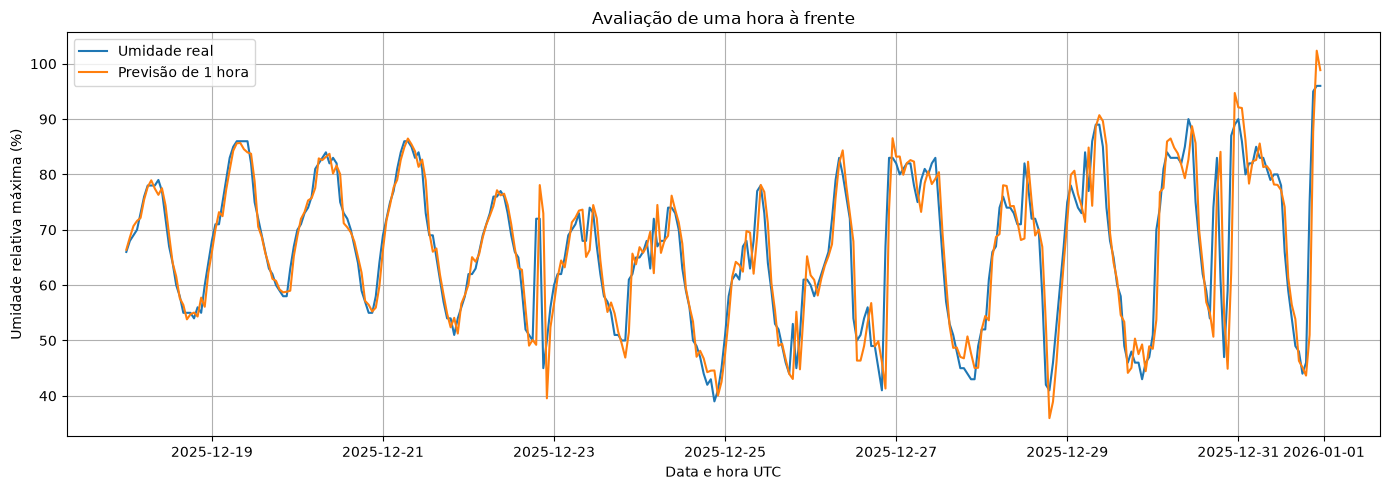


Semente: 20
Perda de treino: 0.041601
Perda de validação: 0.042320
MAE de 1 hora: 2.820
RMSE de 1 hora: 4.519


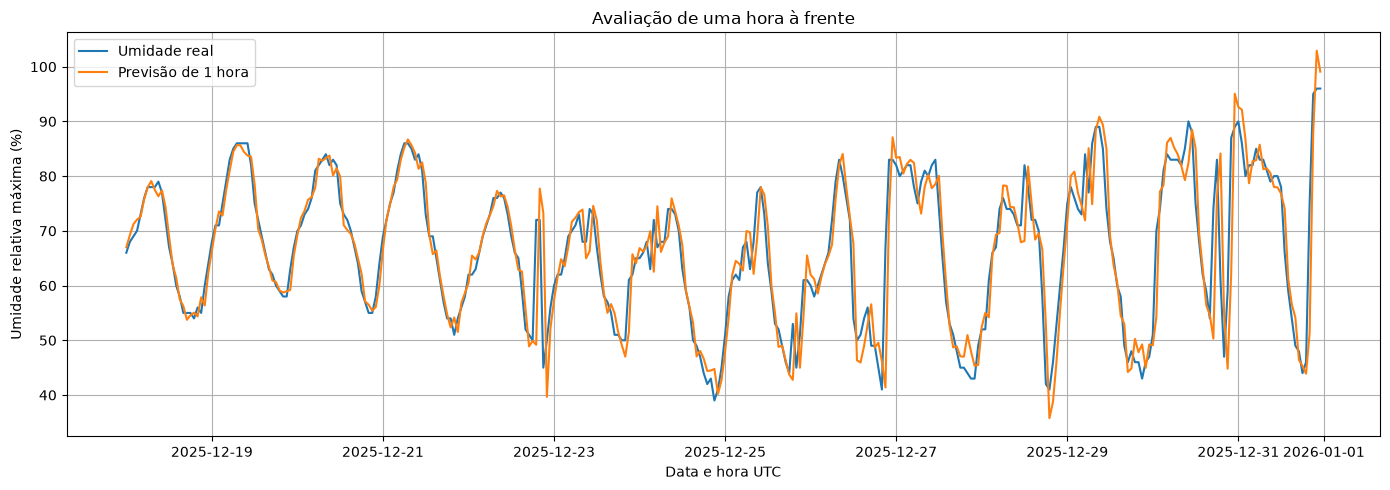


Semente: 30
Perda de treino: 0.041807
Perda de validação: 0.043818
MAE de 1 hora: 2.834
RMSE de 1 hora: 4.526


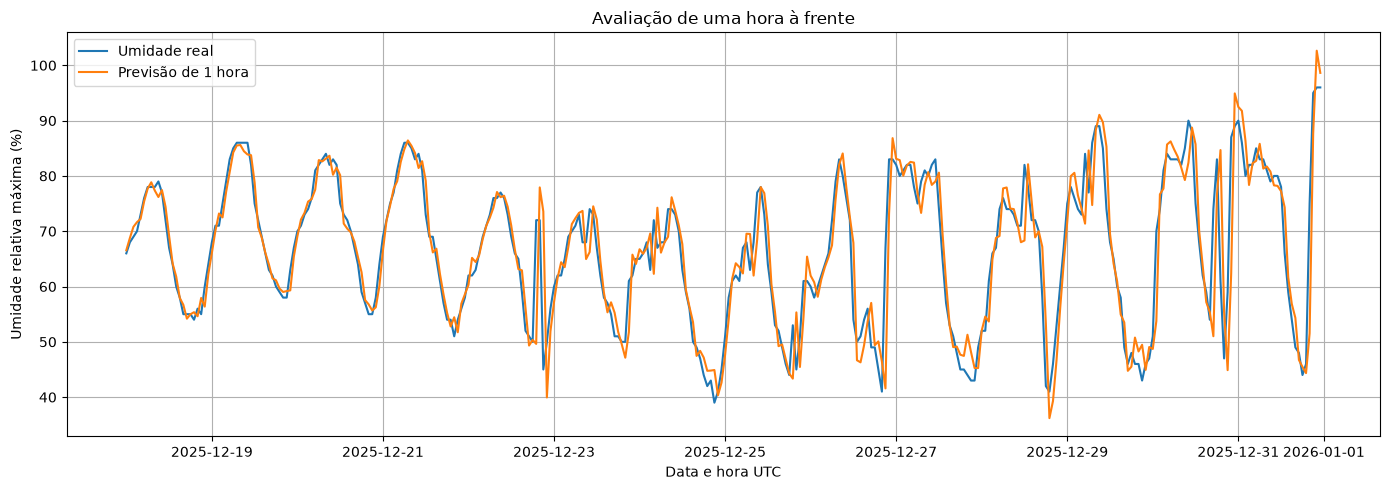


Semente: 40
Perda de treino: 0.041748
Perda de validação: 0.042464
MAE de 1 hora: 2.833
RMSE de 1 hora: 4.540


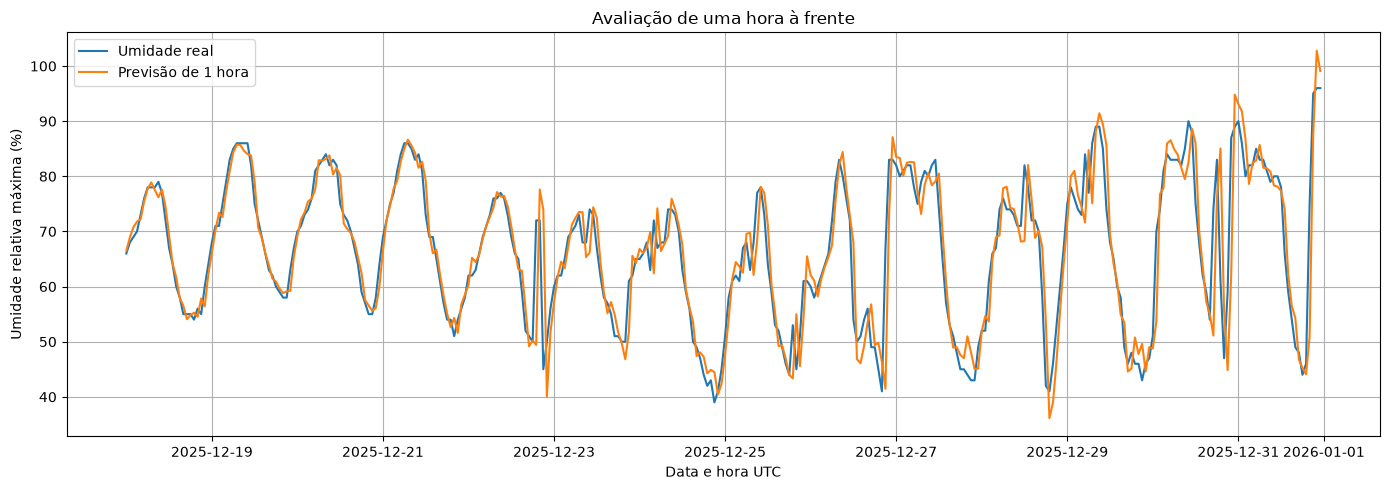


Semente: 50
Perda de treino: 0.041648
Perda de validação: 0.042556
MAE de 1 hora: 2.829
RMSE de 1 hora: 4.517


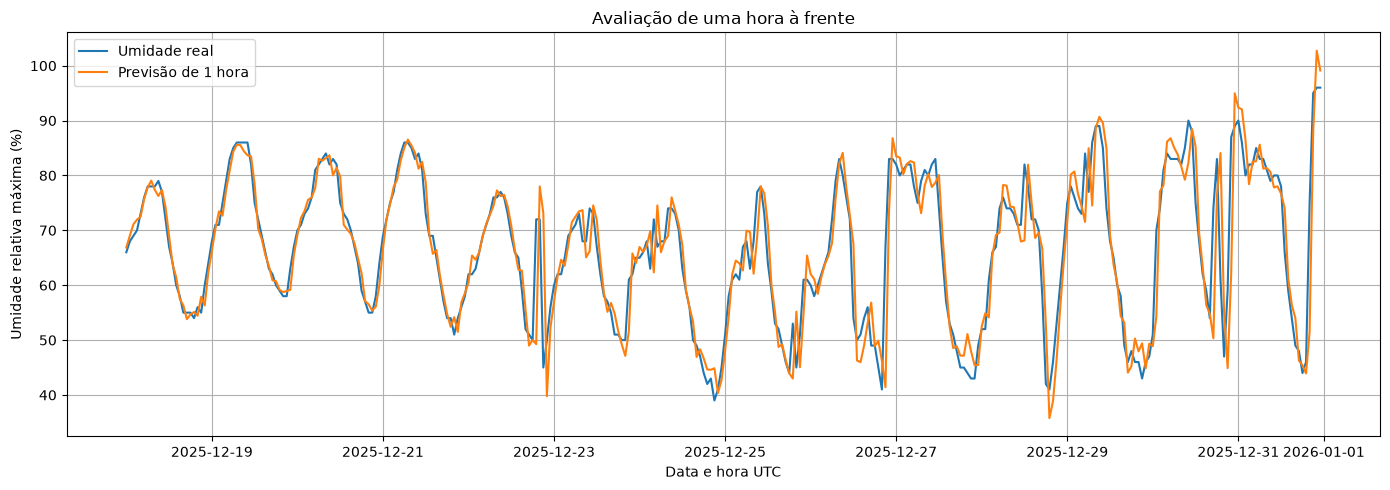


Métricas para o modelo GRU:

Semente: 10
Perda de treino: 0.029171
Perda de validação: 0.047736
MAE de 1 hora: 2.783
RMSE de 1 hora: 4.526


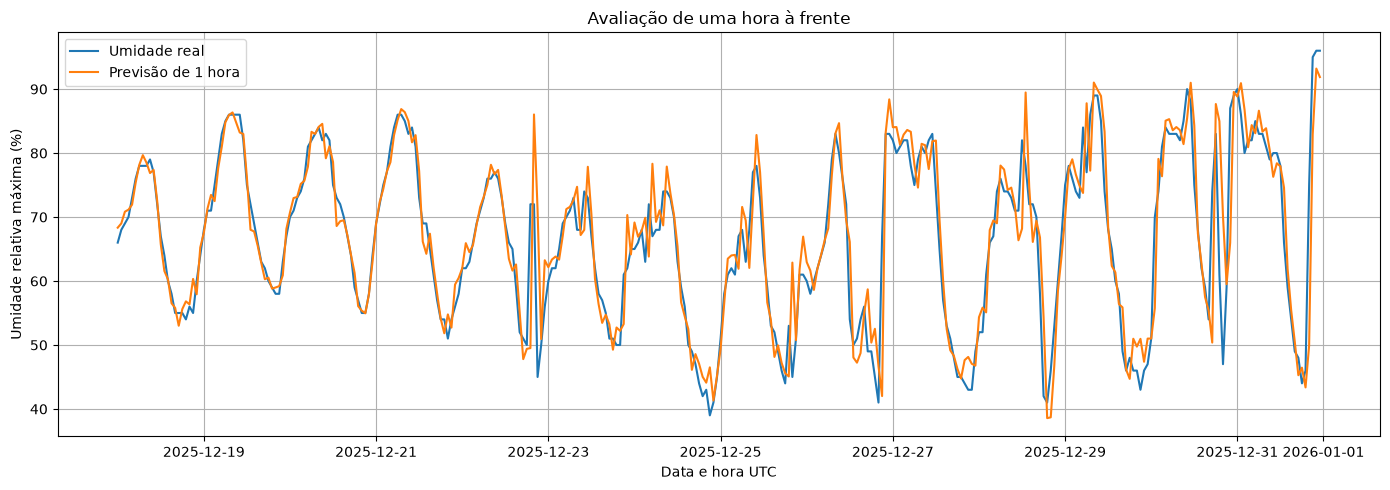


Semente: 20
Perda de treino: 0.031560
Perda de validação: 0.048140
MAE de 1 hora: 2.731
RMSE de 1 hora: 4.411


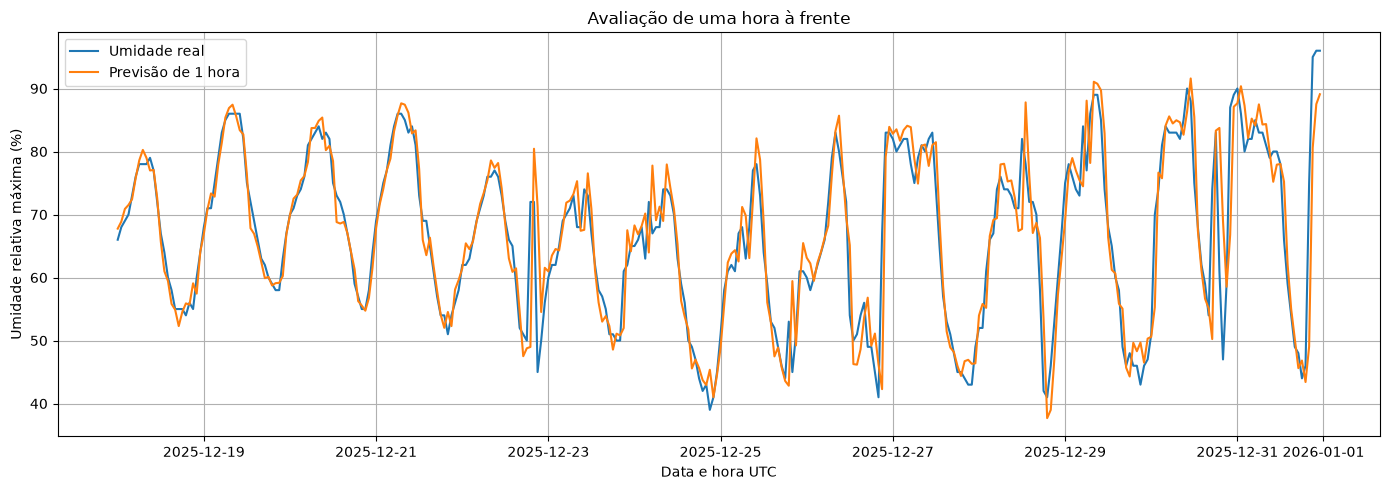


Semente: 30
Perda de treino: 0.029337
Perda de validação: 0.048985
MAE de 1 hora: 2.782
RMSE de 1 hora: 4.479


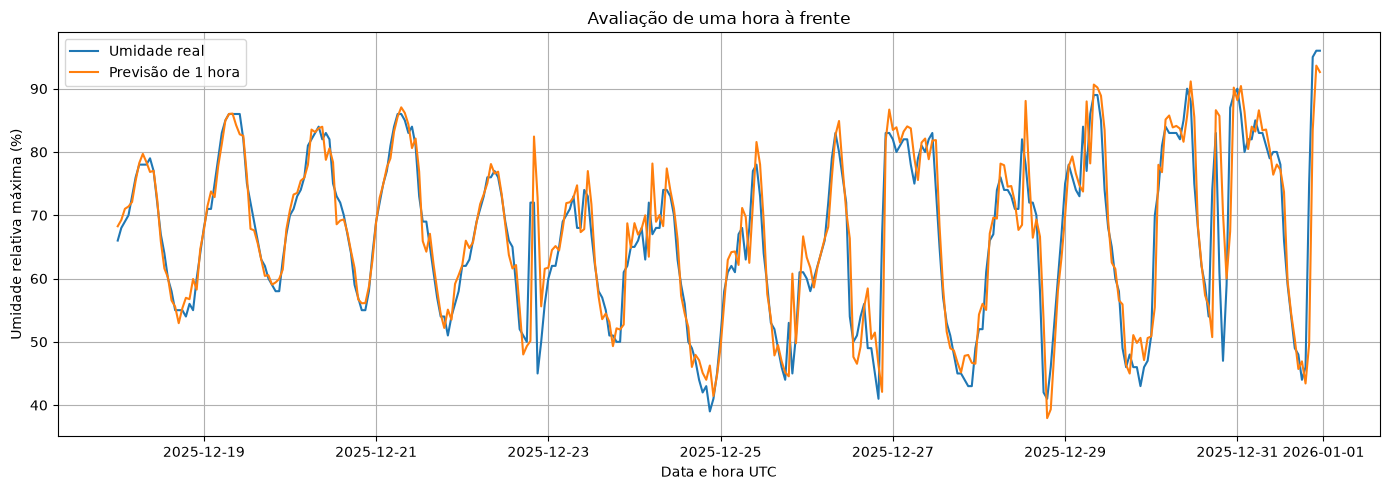


Semente: 40
Perda de treino: 0.031882
Perda de validação: 0.052110
MAE de 1 hora: 2.762
RMSE de 1 hora: 4.409


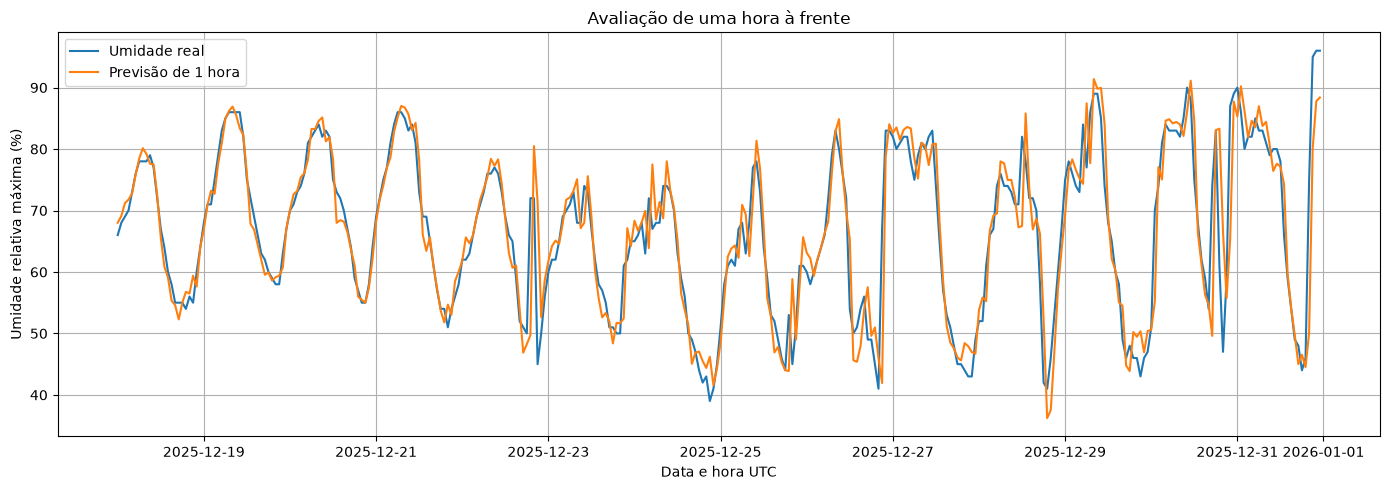


Semente: 50
Perda de treino: 0.031541
Perda de validação: 0.047431
MAE de 1 hora: 2.825
RMSE de 1 hora: 4.473


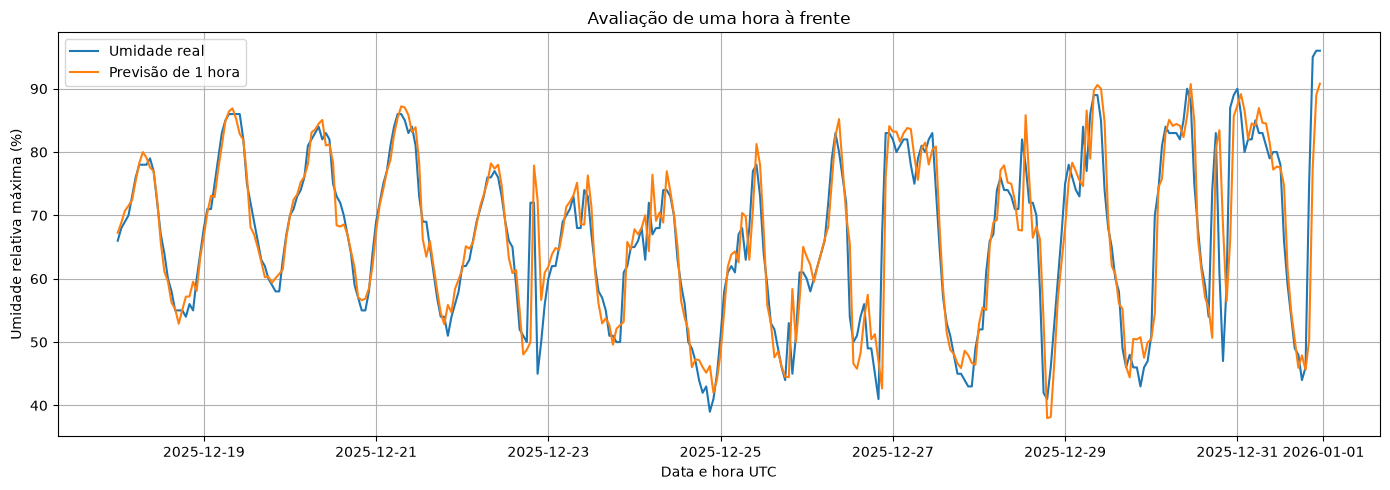

In [18]:
for model in ["Linear", "GRU"]:
    print(f"\nMétricas para o modelo {model}:")

    for i, (modelo, hist) in enumerate(
        zip(
            modelos_treinados[model],
            historicos[model]
        )
    ):
        print(f"\nSemente: {SEMENTES[i]}")

        perda_treino = hist["treino"][-1]
        perda_validacao = hist["validacao"][-1]

        print(f"Perda de treino: {perda_treino:.6f}")
        print(f"Perda de validação: {perda_validacao:.6f}")
        
        X_test_tensor = torch.tensor(
            X_test,
            dtype=torch.float32,
            device=device
        )

        modelo.eval()

        with torch.no_grad():
            pred_one_step_normalizado = (
                modelo(X_test_tensor)
                .squeeze(1)
                .cpu()
                .numpy()
            )

        pred_one_step_origem = (
            pred_one_step_normalizado * desvio_treino
            + media_treino
        )

        real_one_step = (
            y_test.squeeze(1) * desvio_treino
            + media_treino
        )

        # métricas

        mae = np.mean(
            np.abs(real_one_step - pred_one_step_origem)
        )

        rmse = np.sqrt(
            np.mean((real_one_step - pred_one_step_origem) ** 2)
        )

        print(f"MAE de 1 hora: {mae:.3f}")
        print(f"RMSE de 1 hora: {rmse:.3f}")

        # GRÁFICO 

        n_plot = 24 * 14

        plt.figure(figsize=(14, 5))

        plt.plot(
            datas_test[-n_plot:],
            real_one_step[-n_plot:],
            label="Umidade real"
        )

        plt.plot(
            datas_test[-n_plot:],
            pred_one_step_origem[-n_plot:],
            label="Previsão de 1 hora"
        )

        plt.xlabel("Data e hora UTC")
        plt.ylabel("Umidade relativa máxima (%)")
        plt.title("Avaliação de uma hora à frente")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


# 5. Previsão recursiva para 48 E 72 horas

Usaremos como origem o último ponto do treinamento. O modelo não terá acesso aos valores reais do teste durante a geração.

In [19]:
def obter_dispositivo(modelo):
    return next(modelo.parameters()).device

In [20]:
def previsao_sazonal(
    historico_original,
    horizonte,
    periodo=24
):
    historico_original = np.asarray(
        historico_original,
        dtype=np.float32
    )

    if len(historico_original) < periodo:
        raise ValueError(
            "Histórico insuficiente para o período sazonal."
        )

    padrao = historico_original[-periodo:]

    repeticoes = int(
        np.ceil(horizonte / periodo)
    )

    return np.tile(
        padrao,
        repeticoes
    )[:horizonte]

In [21]:
def previsao_recursiva(
    modelo,
    historico_normalizado,
    tau,
    horizonte
):
    modelo.eval()

    device_modelo = obter_dispositivo(modelo)

    if len(historico_normalizado) < tau:
        raise ValueError(
            "O histórico possui menos observações que tau."
        )

    janela = torch.tensor(
        historico_normalizado[-tau:],
        dtype=torch.float32,
        device=device_modelo
    )

    previsoes = []

    with torch.inference_mode():
        for _ in range(horizonte):
            entrada = janela.reshape(1, tau)

            proximo = modelo(entrada).squeeze()

            previsoes.append(float(proximo.item()))

            janela = torch.cat([
                janela[1:],
                proximo.reshape(1)
            ])

    return np.array(previsoes, dtype=np.float32)

In [22]:
def calcular_metricas(real, previsto):
    mae = np.mean(np.abs(real - previsto))
    rmse = np.sqrt(np.mean((real - previsto) ** 2))

    return mae, rmse

## 5.1. Previsão recursiva para 72

In [23]:
# GERANDO 72 HORAS DE PREVISÃO
origem = indice_inicio_teste
horizonte = 72

historico_teste_normalizado = serie_normalizada[:origem]

# Criar um dicionário vazio para armazenar as previsões de cada modelo e o horizonte de previsão
previsoes_modelos = {
    "Linear": [],
    "GRU": []
}

for model in ["Linear", "GRU"]:
    for i, (modelo, hist) in enumerate(
        zip(
            modelos_treinados[model],
            historicos[model]
        )
    ):

        pred_horizonte_normalizado = previsao_recursiva(
            modelo=modelo,
            historico_normalizado=historico_teste_normalizado,
            tau=tau,
            horizonte=horizonte
        )

        pred_horizonte_origem = (
            pred_horizonte_normalizado * desvio_treino
            + media_treino
        )

        if model == "Linear":
            previsoes_modelos["Linear"].append(pred_horizonte_origem)
        elif model == "GRU":
            previsoes_modelos["GRU"].append(pred_horizonte_origem)



        # Verificação
        assert len(pred_horizonte_origem) == horizonte

Previsões para 72 horas


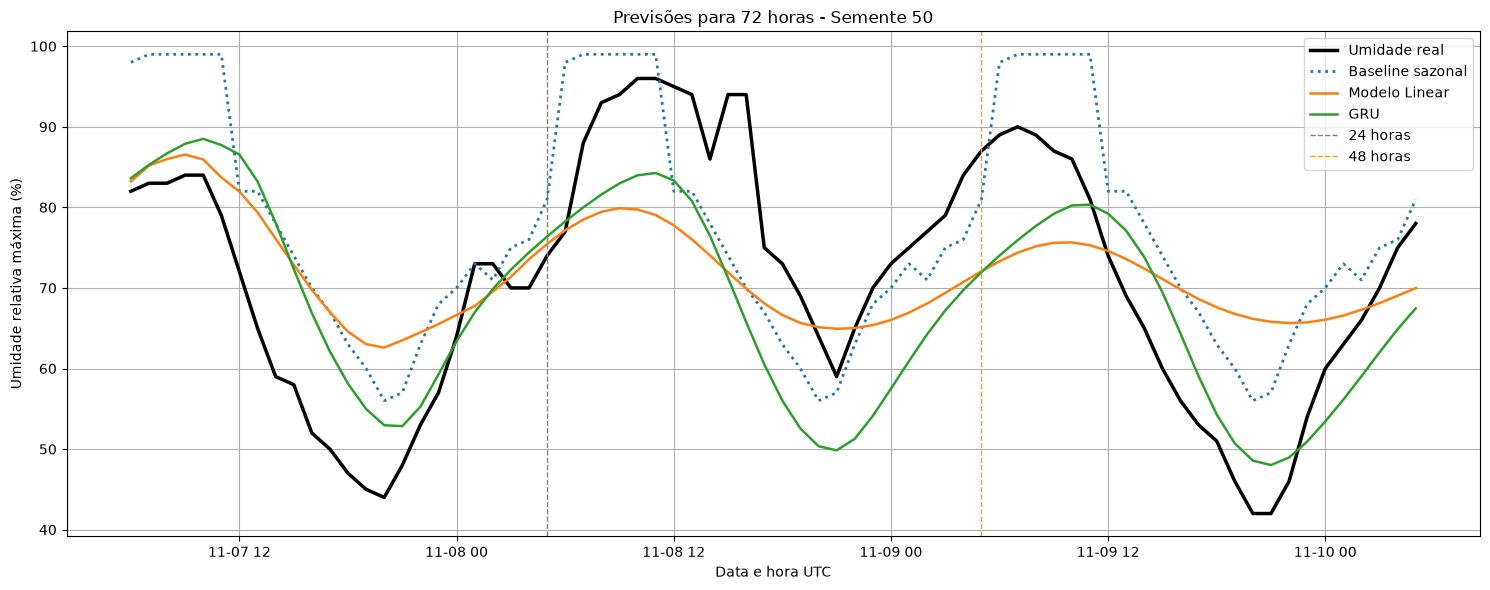

In [88]:
# GRÁFICO horizonte HORAS

real_origem = serie[
    fim_validacao:fim_validacao + horizonte
]

datas_origem = datas[
    fim_validacao:fim_validacao + horizonte
]

pred_baseline_origem = previsao_sazonal(
    historico_original=serie[:origem],
    horizonte=horizonte,
    periodo=24
)

# calcula a média das previsões para cada modelo
media_previsoes = {
    "Linear": np.mean(
        previsoes_modelos["Linear"],
        axis=0
    ),
    "GRU": np.mean(
        previsoes_modelos["GRU"],
        axis=0
    )
}

print(f"Previsões para 72 horas")
previsao_linear = media_previsoes["Linear"]
previsao_gru = media_previsoes["GRU"]

plt.figure(figsize=(15, 6))

plt.plot(
    datas_origem,
    real_origem,
    color="black",
    linewidth=2.5,
    label="Umidade real"
)

plt.plot(
    datas_origem,
    pred_baseline_origem,
    linestyle=":",
    linewidth=2,
    label="Baseline sazonal"
)

plt.plot(
    datas_origem,
    previsao_linear,
    linewidth=1.8,
    label="Modelo Linear"
)

plt.plot(
    datas_origem,
    previsao_gru,
    linewidth=1.8,
    label="GRU"
)

plt.axvline(
    datas_origem[23],
    color="gray",
    linestyle="--",
    linewidth=1,
    label="24 horas"
)

plt.axvline(
    datas_origem[47],
    color="orange",
    linestyle="--",
    linewidth=1,
    label="48 horas"
)

plt.xlabel("Data e hora UTC")
plt.ylabel("Umidade relativa máxima (%)")
plt.title(
    f"Previsões para 72 horas - Semente {semente}"
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 5.2.1. Como comparar o desempenho dentro das primeiras 12h, 24h, 36h, 48h, 60h e 72h

Isso mede a qualidade da trajetória completa até cada horizonte.

In [80]:
previsoes_modelos
# calcula a média das previsões para cada modelo
media_previsoes = {
    "Linear": np.mean(
        previsoes_modelos["Linear"],
        axis=0
    ),
    "GRU": np.mean(
        previsoes_modelos["GRU"],
        axis=0
    )
}

In [86]:
for model in ["Linear", "GRU"]:
    for horizonte in [12, 24, 36, 48, 60, 72]:
        if model == "Linear":
            pred_horizonte_origem = media_previsoes["Linear"][:horizonte]
        elif model == "GRU":
            pred_horizonte_origem = media_previsoes["GRU"][:horizonte]
        mae_h, rmse_h = calcular_metricas(
            real_origem[:horizonte],
            pred_horizonte_origem[:horizonte]
        )
        if model == "Linear":
            print(
                f"Modelo Linear - Horizonte acumulado de {horizonte:02d} horas | "
                f"MAE = {mae_h:.3f} | "
                f"RMSE = {rmse_h:.3f}"
            )
        elif model == "GRU":
            print(
                f"Modelo GRU - Horizonte acumulado de {horizonte:02d} horas | "
                f"MAE = {mae_h:.3f} | "
                f"RMSE = {rmse_h:.3f}"
            )



# diferença entre modelos por horizonte

print("\n")
for horizonte in [12, 24, 36, 48, 60, 72]:
    pred_linear = media_previsoes["Linear"][:horizonte]
    pred_gru = media_previsoes["GRU"][:horizonte]
    mae_linear, rmse_linear = calcular_metricas(
        real_origem[:horizonte],
        pred_linear
    )
    mae_gru, rmse_gru = calcular_metricas(
        real_origem[:horizonte],
        pred_gru
    )
    print(
        f"Horizonte acumulado de {horizonte:02d} horas | "
        f"Diferença MAE Linear - GRU = {mae_linear - mae_gru:.3f} | "
        f"Diferença RMSE Linear - GRU = {rmse_linear - rmse_gru:.3f}"
    )

Modelo Linear - Horizonte acumulado de 12 horas | MAE = 8.889 | RMSE = 11.072
Modelo Linear - Horizonte acumulado de 24 horas | MAE = 8.921 | RMSE = 11.102
Modelo Linear - Horizonte acumulado de 36 horas | MAE = 10.690 | RMSE = 12.758
Modelo Linear - Horizonte acumulado de 48 horas | MAE = 9.750 | RMSE = 11.773
Modelo Linear - Horizonte acumulado de 60 horas | MAE = 9.895 | RMSE = 11.718
Modelo Linear - Horizonte acumulado de 72 horas | MAE = 10.238 | RMSE = 12.232
Modelo GRU - Horizonte acumulado de 12 horas | MAE = 9.830 | RMSE = 11.605
Modelo GRU - Horizonte acumulado de 24 horas | MAE = 7.342 | RMSE = 9.196
Modelo GRU - Horizonte acumulado de 36 horas | MAE = 9.208 | RMSE = 11.248
Modelo GRU - Horizonte acumulado de 48 horas | MAE = 10.433 | RMSE = 12.071
Modelo GRU - Horizonte acumulado de 60 horas | MAE = 10.023 | RMSE = 11.551
Modelo GRU - Horizonte acumulado de 72 horas | MAE = 9.403 | RMSE = 10.898


Horizonte acumulado de 12 horas | Diferença MAE Linear - GRU = -0.941 | Difer

# 6. Avaliação de múltiplas origens em várias janelas de 12h, 24h, 36h, 48h, 60h e 72h

## 6.1. Avaliação da baseline sazonal 

### 6.1.1. Avaliação do baseline com as mesmas origens

In [26]:
def avaliar_baseline_sazonal(
    serie_original,
    indice_inicio_avaliacao,
    indice_fim_avaliacao,
    horizontes=(12, 24, 36, 48, 60, 72),
    passo_origem=12,
    periodo=24
):
    horizonte_maximo = max(horizontes)

    resultados = {
        h: {
            "residuos": [],
            "mae_por_origem": [],
            "rmse_por_origem": [],
            "origens": []
        }
        for h in horizontes
    }

    ultimo_inicio = (
        indice_fim_avaliacao
        - horizonte_maximo
    )

    for origem in range(
        indice_inicio_avaliacao,
        ultimo_inicio + 1,
        passo_origem
    ):
        historico = serie_original[:origem]

        pred = previsao_sazonal(
            historico_original=historico,
            horizonte=horizonte_maximo,
            periodo=periodo
        )

        real = serie_original[
            origem:origem + horizonte_maximo
        ]

        for h in horizontes:
            residuos_h = (
                real[:h] - pred[:h]
            )

            resultados[h]["residuos"].extend(
                residuos_h.tolist()
            )

            resultados[h][
                "mae_por_origem"
            ].append(
                np.mean(np.abs(residuos_h))
            )

            resultados[h][
                "rmse_por_origem"
            ].append(
                np.sqrt(
                    np.mean(residuos_h ** 2)
                )
            )

            resultados[h]["origens"].append(
                origem
            )

    return resultados

In [27]:
resultados_baseline_teste = avaliar_baseline_sazonal(
        serie_original=serie,
        indice_inicio_avaliacao=fim_validacao,
        indice_fim_avaliacao=len(serie),
        horizontes=(12, 24, 36, 48, 60, 72),
        passo_origem=12,
        periodo=24
    )

## 6.2. Avaliação dos Modelos 

### 6.2.1. Avaliação dos modelos com as mesmas origens

In [ ]:
def avaliar_horizontes_acumulados(
    modelo,
    serie_normalizada,
    serie_original,
    indice_inicio_avaliacao,
    indice_fim_avaliacao,
    tau,
    media_treino,
    desvio_treino,
    horizontes=(12, 24, 36, 48, 60, 72),
    passo_origem=4
):
    horizonte_maximo = max(horizontes)

    resultados = {
        h: {
            "residuos": [],
            "mae_por_origem": [],
            "rmse_por_origem": [],
            "origens": []
        }
        for h in horizontes
    }

    ultimo_inicio = (
        indice_fim_avaliacao
        - horizonte_maximo
    )

    for origem in range(
        indice_inicio_avaliacao,
        ultimo_inicio + 1,
        passo_origem
    ):
        historico = serie_normalizada[:origem]

        pred_norm = previsao_recursiva(
            modelo=modelo,
            historico_normalizado=historico,
            tau=tau,
            horizonte=horizonte_maximo
        )

        pred = (
            pred_norm * desvio_treino
            + media_treino
        )

        real = serie_original[
            origem:origem + horizonte_maximo
        ]

        for h in horizontes:
            residuos_h = (
                real[:h] - pred[:h]
            )

            resultados[h]["residuos"].extend(
                residuos_h.tolist()
            )

            resultados[h][
                "mae_por_origem"
            ].append(
                np.mean(np.abs(residuos_h))
            )

            resultados[h][
                "rmse_por_origem"
            ].append(
                np.sqrt(
                    np.mean(residuos_h ** 2)
                )
            )

            resultados[h]["origens"].append(
                origem
            )

    return resultados

#### 6.2.1.1. Avaliar todos os modelos carregados em sequência

In [30]:
resultados_modelos_teste = {
    "Linear": [],
    "GRU": []
}

for nome_modelo in ["Linear", "GRU"]:
    for modelo in modelos_treinados[nome_modelo]:

        resultado = avaliar_horizontes_acumulados(
            modelo=modelo,
            serie_normalizada=serie_normalizada,
            serie_original=serie,
            indice_inicio_avaliacao=fim_validacao,
            indice_fim_avaliacao=len(serie),
            tau=tau,
            media_treino=media_treino,
            desvio_treino=desvio_treino,
            horizontes=(12, 24, 36, 48, 60, 72),
            passo_origem=12
        )

        resultados_modelos_teste[
            nome_modelo
        ].append(resultado)

#### 6.2.1.2. Avaliar um modelo linear

In [52]:
modelo_linear, meta_linear = carregar_checkpoint(
    caminho=caminho_linear,
    dispositivo="cpu"
)
tau_linear = int(meta_linear["tau"])
media_linear = float(meta_linear["media_treino"])
desvio_linear = float(meta_linear["desvio_treino"])

serie_normalizada_linear = (
    (serie - media_linear) / desvio_linear
).astype(np.float32)


resultados_linear_carregado = avaliar_horizontes_acumulados(
    modelo=modelo_linear,
    serie_normalizada=serie_normalizada_linear,
    serie_original=serie,
    indice_inicio_avaliacao=fim_validacao,
    indice_fim_avaliacao=len(serie),
    tau=tau_linear,
    media_treino=media_linear,
    desvio_treino=desvio_linear,
    horizontes=(12, 24, 36, 48, 60, 72),
    passo_origem=12
)


NameError: name 'meta_linear' is not defined

#### 6.2.1.3. Avaliar um modelo GRU

In [ ]:
tau_gru = int(meta_gru["tau"])
media_gru = float(meta_gru["media_treino"])
desvio_gru = float(meta_gru["desvio_treino"])

serie_normalizada_gru = (
    (serie - media_gru) / desvio_gru
).astype(np.float32)

resultados_gru_carregado = avaliar_horizontes_acumulados(
    modelo=modelo_gru,
    serie_normalizada=serie_normalizada_gru,
    serie_original=serie,
    indice_inicio_avaliacao=fim_validacao,
    indice_fim_avaliacao=len(serie),
    tau=tau_gru,
    media_treino=media_gru,
    desvio_treino=desvio_gru,
    horizontes=(12, 24, 36, 48, 60, 72),
    passo_origem=12
)

### 6.3. Resumo dos resultados


In [31]:
def resumir_resultados(resultados):
    resumo = []

    for horizonte, dados in resultados.items():
        residuos = np.asarray(
            dados["residuos"],
            dtype=float
        )

        mae = np.mean(np.abs(residuos))

        rmse = np.sqrt(
            np.mean(residuos ** 2)
        )

        mediana_abs = np.median(
            np.abs(residuos)
        )

        resumo.append({
            "horizonte": horizonte,
            "mae": mae,
            "rmse": rmse,
            "mediana_absoluta": mediana_abs,
            "n_origens": len(
                dados["mae_por_origem"]
            ),
            "n_previsoes": len(residuos)
        })

    return pd.DataFrame(resumo)

### 6.3.1. Resumo individualizado

In [ ]:
resumo_baseline_carregado = resumir_resultados(
    resultados_baseline_teste
)
resumo_linear_carregado = resumir_resultados(
    resultados_linear_carregado
)

resumo_gru_carregado = resumir_resultados(
    resultados_gru_carregado
)

print("Baseline Sazonal")
print(resumo_baseline_carregado)

print("\nModelo Linear")
print(resumo_linear_carregado)

print("\nGRU")
print(resumo_gru_carregado)

### 6.3.2. Avaliação e resumo de todos os modelos

#### 6.3.2.1. Avaliação e resumo de todos modelos de uma execução carregados 

In [32]:
resumo_resultado_sementes = []

def criar_resumo_baseline(
    serie_original,
    indice_inicio_avaliacao,
    indice_fim_avaliacao,
    horizontes=(12, 24, 36, 48, 60, 72),
    passo_origem=12,
    periodo=24
):
    resultado_baseline = avaliar_baseline_sazonal(
        serie_original=serie_original,
        indice_inicio_avaliacao=indice_inicio_avaliacao,
        indice_fim_avaliacao=indice_fim_avaliacao,
        horizontes=horizontes,
        passo_origem=passo_origem,
        periodo=periodo
    )

    resumo_baseline = resumir_resultados(
        resultado_baseline
    )

    resumo_baseline["modelo"] = "Baseline Sazonal"
    resumo_baseline["semente"] = None

    return resumo_baseline


resumo_baseline = criar_resumo_baseline(
    serie_original=serie,
    indice_inicio_avaliacao=fim_validacao,
    indice_fim_avaliacao=len(serie)
)

resumo_resultado_sementes.append(resumo_baseline)

for nome_modelo in ["Linear", "GRU"]:
    for semente, modelo in zip(
        SEMENTES,
        modelos_treinados[nome_modelo]
    ):
        resultados = avaliar_horizontes_acumulados(
            modelo=modelo,
            serie_normalizada=serie_normalizada,
            serie_original=serie,
            indice_inicio_avaliacao=fim_validacao,
            indice_fim_avaliacao=len(serie),
            tau=tau,
            media_treino=media_treino,
            desvio_treino=desvio_treino,
            horizontes=(12, 24, 36, 48, 60, 72),
            passo_origem=12
        )

        resumo = resumir_resultados(resultados)

        resumo["modelo"] = nome_modelo
        resumo["semente"] = semente

        resumo_resultado_sementes.append(resumo)

resumo_final = pd.concat(
    resumo_resultado_sementes,
    ignore_index=True
)

#### 6.3.2.2. Avaliação e resumo de um checkpoint por vez para economizar memória

In [ ]:
def extrair_semente_do_nome(caminho):
    return int(
        caminho.name
        .split("semente-")[1]
        .split("_")[0]
    )


resumos_carregados = []

for nome_modelo in ["Linear", "GRU"]:
    arquivos = list(
        PASTA_MODELOS.glob(
            f"{nome_modelo.lower()}_"
            f"semente-*_{ID_EXECUCAO}.pth"
        )
    )

    arquivos = sorted(
        arquivos,
        key=extrair_semente_do_nome
    )

    for caminho in arquivos:
        modelo, meta = carregar_checkpoint(
            caminho=caminho,
            dispositivo="cpu"
        )

        serie_norm = (
            (serie - meta["media_treino"])
            / meta["desvio_treino"]
        ).astype(np.float32)

        resultados = avaliar_horizontes_acumulados(
            modelo=modelo,
            serie_normalizada=serie_norm,
            serie_original=serie,
            indice_inicio_avaliacao=fim_validacao,
            indice_fim_avaliacao=len(serie),
            tau=meta["tau"],
            media_treino=meta["media_treino"],
            desvio_treino=meta["desvio_treino"],
            horizontes=(12, 24, 36, 48, 60, 72),
            passo_origem=12
        )

        resumo = resumir_resultados(resultados)
        resumo["modelo"] = nome_modelo
        resumo["semente"] = meta["semente"]
        resumo["arquivo"] = caminho.name

        resumos_carregados.append(resumo)

        # Remove o modelo antes de carregar o próximo.
        modelo.to("cpu")
        del modelo
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

resumo_final = pd.concat(
    resumos_carregados,
    ignore_index=True
)

#### 6.3.2.3. Salvar também as métricas em CSV

Os modelos preservam os pesos. Para reprodutibilidade, também é útil salvar as tabelas de métricas.



In [37]:
caminho_metricas = (
    PASTA_MODELOS
    / f"metricas_{ID_EXECUCAO}.csv"
)

resumo_final.to_csv(
    caminho_metricas,
    index=False,
    encoding="utf-8-sig"
)

print("Métricas salvas em:", caminho_metricas)

Métricas salvas em: modelos_salvos\metricas_2026-09-17_20-35-31.csv


Se quiser salvar o resumo final:

In [38]:
caminho_resumo = (
    PASTA_MODELOS
    / f"resumo_final_{ID_EXECUCAO}.csv"
)

resumo_final.to_csv(
    caminho_resumo,
    index=False,
    encoding="utf-8-sig"
)

#### 6.3.2.3. Erro global de todas as previsões por horizonte

Junta todos os resíduos de todas as origens:

In [39]:
resumo_final = (
    resumo_final
    .groupby(["modelo", "horizonte"])
    .agg(
        mae_media=("mae", "mean"),
        mae_dp=("mae", "std"),
        rmse_media=("rmse", "mean"),
        rmse_dp=("rmse", "std"),
        execucoes=("semente", "nunique")
    )
    .reset_index()
)

print(resumo_final)

              modelo  horizonte  mae_media    mae_dp  rmse_media   rmse_dp  \
0   Baseline Sazonal         12  11.181891       NaN   15.537150       NaN   
1   Baseline Sazonal         24  11.162660       NaN   15.522755       NaN   
2   Baseline Sazonal         36  12.360310       NaN   17.038614       NaN   
3   Baseline Sazonal         48  12.961138       NaN   17.747269       NaN   
4   Baseline Sazonal         60  13.794551       NaN   18.576893       NaN   
5   Baseline Sazonal         72  14.347222       NaN   19.108866       NaN   
6                GRU         12   8.905195  0.292137   12.314653  0.452626   
7                GRU         24  10.117905  0.707122   13.790231  0.934701   
8                GRU         36  11.476475  0.812510   15.544509  1.259566   
9                GRU         48  12.460852  1.271406   16.794342  1.859421   
10               GRU         60  13.424127  1.609190   17.968359  2.312806   
11               GRU         72  14.192918  2.066261   18.932548

# 7. Gráficos

## 7.1. MAE médio por horizonte

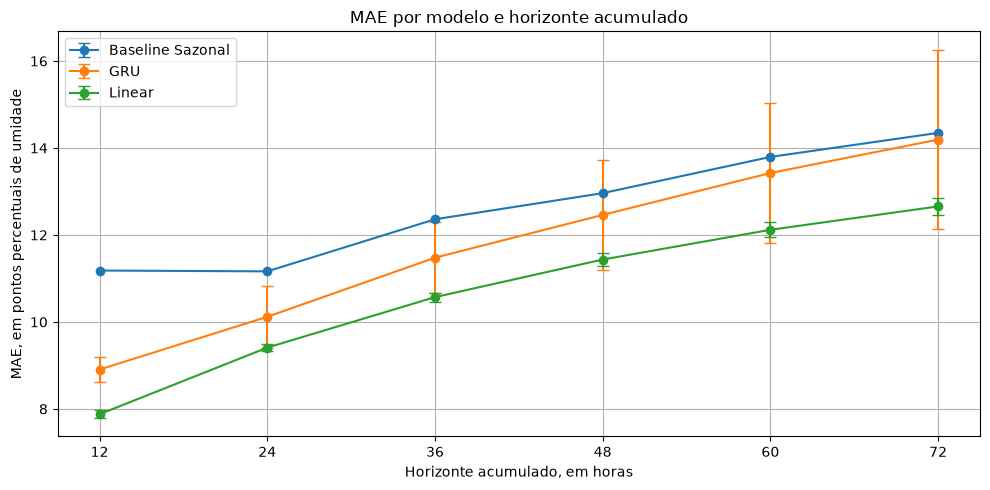

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))

for modelo, grupo in resumo_final.groupby("modelo"):
    ax.errorbar(
        grupo["horizonte"],
        grupo["mae_media"],
        yerr=grupo["mae_dp"],
        marker="o",
        capsize=4,
        label=modelo
    )

ax.set_xlabel("Horizonte acumulado, em horas")
ax.set_ylabel(
    "MAE, em pontos percentuais de umidade"
)
ax.set_title(
    "MAE por modelo e horizonte acumulado"
)
ax.set_xticks([12, 24, 36, 48, 60, 72])
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 7.2 RMSE médio por horizonte

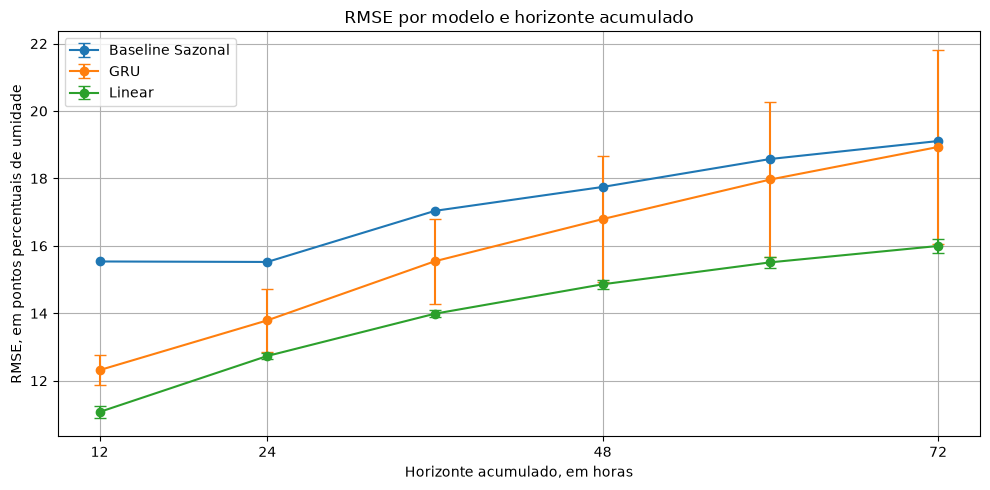

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))

for modelo, grupo in resumo_final.groupby("modelo"):
    ax.errorbar(
        grupo["horizonte"],
        grupo["rmse_media"],
        yerr=grupo["rmse_dp"],
        marker="o",
        capsize=4,
        label=modelo
    )

ax.set_xlabel("Horizonte acumulado, em horas")
ax.set_ylabel(
    "RMSE, em pontos percentuais de umidade"
)
ax.set_title(
    "RMSE por modelo e horizonte acumulado"
)
ax.set_xticks([12, 24, 48, 72])
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 7.3. Boxplot do MAE por origem

In [42]:
def obter_mae_medio_por_origem(
    lista_resultados,
    horizonte
):
    matriz = np.vstack([
        resultado[horizonte]["mae_por_origem"]
        for resultado in lista_resultados
    ])

    return {
        "media": matriz.mean(axis=0),
        "desvio_padrao": matriz.std(
            axis=0,
            ddof=1
        ),
        "matriz": matriz
    }

In [43]:
mae_linear = obter_mae_medio_por_origem(
    resultados_modelos_teste["Linear"],
    horizonte=72
)

mae_gru = obter_mae_medio_por_origem(
    resultados_modelos_teste["GRU"],
    horizonte=72
)

In [44]:
mae_linear_por_origem = mae_linear["media"]
mae_gru_por_origem = mae_gru["media"]

12 h | Baseline: 104 | Linear: 104 | GRU: 104


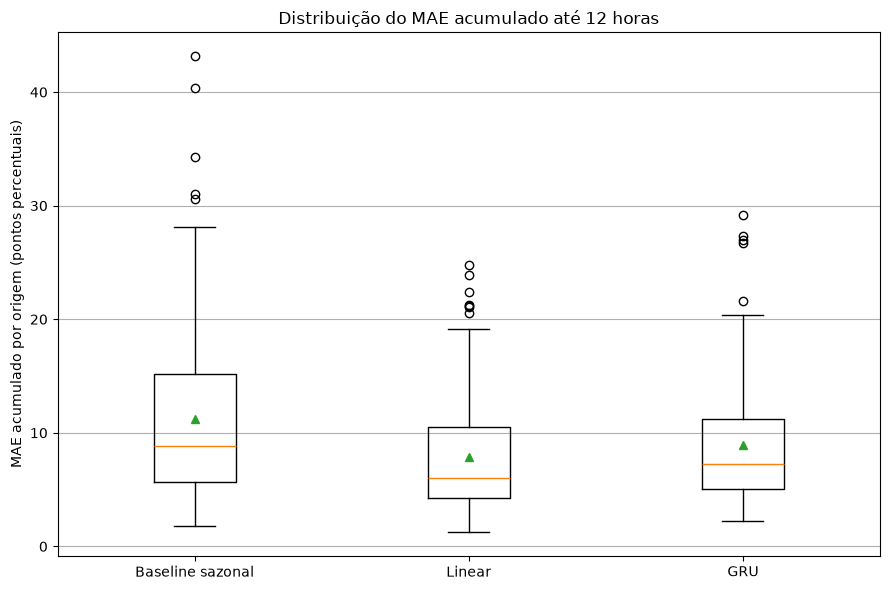

24 h | Baseline: 104 | Linear: 104 | GRU: 104


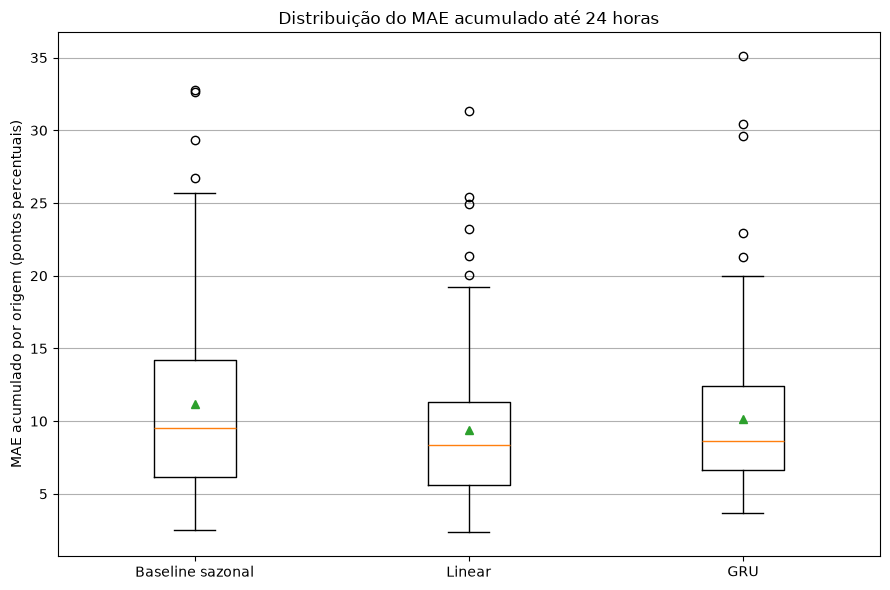

48 h | Baseline: 104 | Linear: 104 | GRU: 104


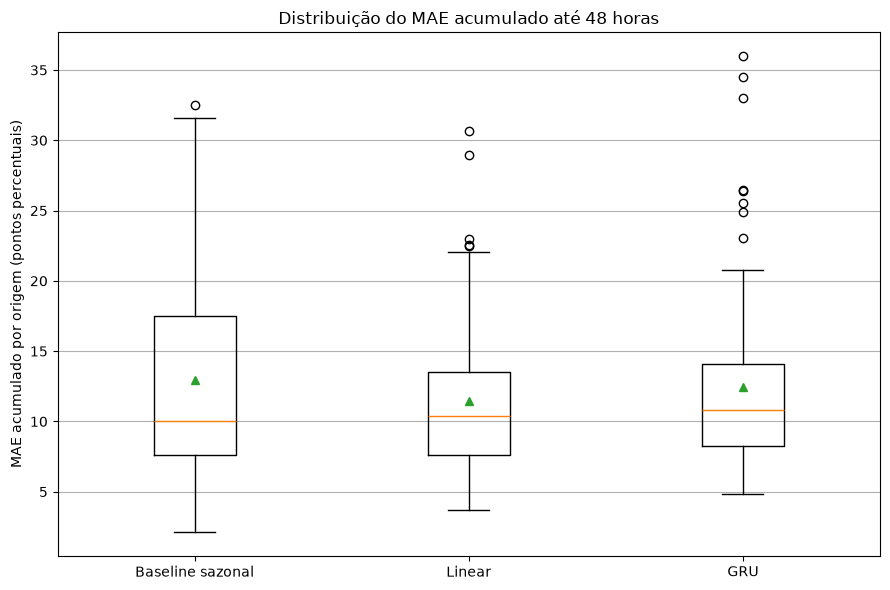

72 h | Baseline: 104 | Linear: 104 | GRU: 104


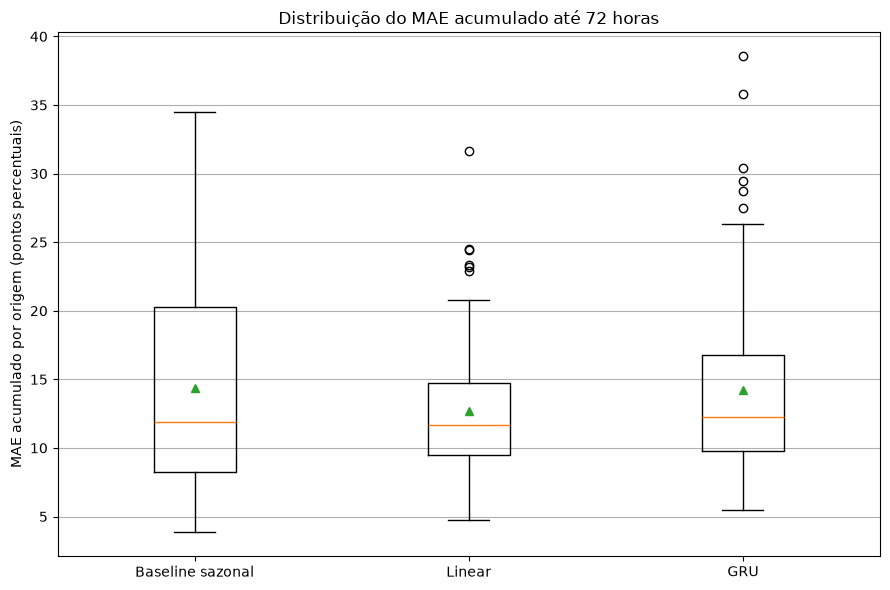

In [45]:
HORIZONTES = (12, 24, 36, 48, 60, 72)

for horizonte in [12, 24, 48, 72]:

    mae_linear_h = obter_mae_medio_por_origem(
        resultados_modelos_teste["Linear"],
        horizonte
    )["media"]

    mae_gru_h = obter_mae_medio_por_origem(
        resultados_modelos_teste["GRU"],
        horizonte
    )["media"]

    mae_baseline_h = np.asarray(
        resultados_baseline_teste[
            horizonte
        ]["mae_por_origem"],
        dtype=float
    )

    print(
        f"{horizonte} h | "
        f"Baseline: {len(mae_baseline_h)} | "
        f"Linear: {len(mae_linear_h)} | "
        f"GRU: {len(mae_gru_h)}"
    )

    assert (
        len(mae_baseline_h)
        == len(mae_linear_h)
        == len(mae_gru_h)
    )

    plt.figure(figsize=(9, 6))

    plt.boxplot(
        [
            mae_baseline_h,
            mae_linear_h,
            mae_gru_h
        ],
        tick_labels=[
            "Baseline sazonal",
            "Linear",
            "GRU"
        ],
        showmeans=True
    )

    plt.ylabel(
        "MAE acumulado por origem "
        "(pontos percentuais)"
    )

    plt.title(
        f"Distribuição do MAE acumulado "
        f"até {horizonte} horas"
    )

    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()

## 7.4. Trajetória comparativa de 72 horas

### 7.4.1. Definindo variáveis de tempo e valores de origem

In [46]:
horizonte_grafico = 72
origem_grafico = fim_validacao

In [47]:
datas_origem = datas[
    origem_grafico:
    origem_grafico + horizonte_grafico
]

real_origem = serie[
    origem_grafico:
    origem_grafico + horizonte_grafico
]

In [48]:
historico_normalizado_origem = (
    serie_normalizada[:origem_grafico]
)

historico_original_origem = (
    serie[:origem_grafico]
)

### 7.4.2. Previsão de baseline

In [49]:
pred_baseline_origem = previsao_sazonal(
    historico_original=historico_original_origem,
    horizonte=horizonte_grafico,
    periodo=24
)

### 7.4.3. Média das previsões das cinco sementes por modelo

In [50]:
# Sementes do modelo linear 

previsoes_linear_sementes = []

for modelo in modelos_treinados["Linear"]:

    pred_normalizado = previsao_recursiva(
        modelo=modelo,
        historico_normalizado=historico_normalizado_origem,
        tau=tau,
        horizonte=horizonte_grafico
    )

    pred = (
        pred_normalizado * desvio_treino
        + media_treino
    )

    previsoes_linear_sementes.append(pred)

previsoes_linear_sementes = np.vstack(
    previsoes_linear_sementes
)

pred_linear_origem = (
    previsoes_linear_sementes.mean(axis=0)
)

dp_linear_origem = (
    previsoes_linear_sementes.std(
        axis=0,
        ddof=1
    )
)

In [51]:
# Sementes do modelo GRU 

previsoes_gru_sementes = []

for modelo in modelos_treinados["GRU"]:

    pred_norm = previsao_recursiva(
        modelo=modelo,
        historico_normalizado=historico_normalizado_origem,
        tau=tau,
        horizonte=horizonte_grafico
    )

    pred = (
        pred_norm * desvio_treino
        + media_treino
    )

    previsoes_gru_sementes.append(pred)

previsoes_gru_sementes = np.vstack(
    previsoes_gru_sementes
)

pred_gru_origem = (
    previsoes_gru_sementes.mean(axis=0)
)

dp_gru_origem = (
    previsoes_gru_sementes.std(
        axis=0,
        ddof=1
    )
)

### 7.4.4. Gráfico integrado de previsões

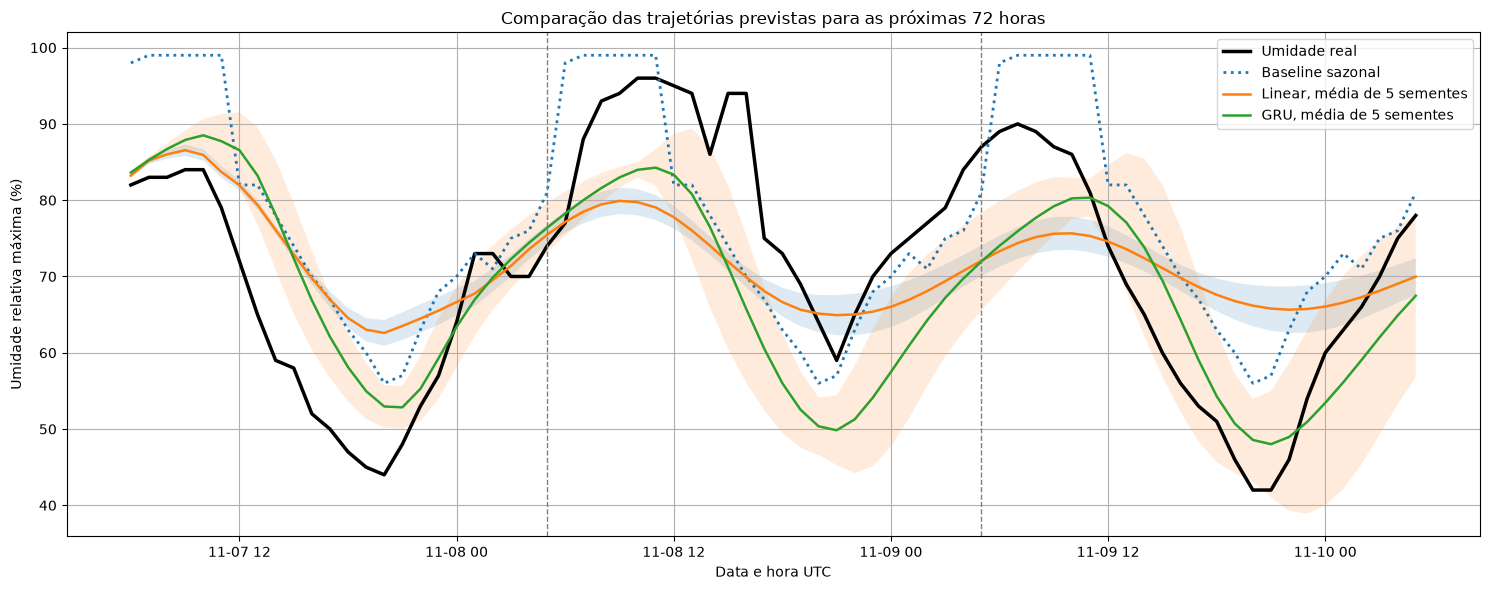

In [52]:
plt.figure(figsize=(15, 6))

plt.plot(
    datas_origem,
    real_origem,
    color="black",
    linewidth=2.5,
    label="Umidade real"
)

plt.plot(
    datas_origem,
    pred_baseline_origem,
    linestyle=":",
    linewidth=2,
    label="Baseline sazonal"
)

plt.plot(
    datas_origem,
    pred_linear_origem,
    linewidth=1.8,
    label="Linear, média de 5 sementes"
)

plt.fill_between(
    datas_origem,
    pred_linear_origem - dp_linear_origem,
    pred_linear_origem + dp_linear_origem,
    alpha=0.15
)

plt.plot(
    datas_origem,
    pred_gru_origem,
    linewidth=1.8,
    label="GRU, média de 5 sementes"
)

plt.fill_between(
    datas_origem,
    pred_gru_origem - dp_gru_origem,
    pred_gru_origem + dp_gru_origem,
    alpha=0.15
)

plt.axvline(
    datas_origem[23],
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.axvline(
    datas_origem[47],
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Data e hora UTC")
plt.ylabel("Umidade relativa máxima (%)")

plt.title(
    "Comparação das trajetórias previstas "
    "para as próximas 72 horas"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. Teste de hipótese entre Linear e GRU

### Hipóteses
$$
H_0: \text{não há diferença de desempenho entre os modelos}
$$
$$
H_1: \text{há diferença de desempenho entre os modelos}
$$

## 8.1. Reavaliação com passo de 72 horas

Como o horizonte máximo é 72 horas, use origens não sobrepostas:

In [55]:
resultados_hipotese = {
    "Linear": [],
    "GRU": []
}
HORIZONTE = 12
for nome_modelo in ["Linear", "GRU"]:
    for modelo in modelos_treinados[nome_modelo]:

        resultado = avaliar_horizontes_acumulados(
            modelo=modelo,
            serie_normalizada=serie_normalizada,
            serie_original=serie,
            indice_inicio_avaliacao=fim_validacao,
            indice_fim_avaliacao=len(serie),
            tau=tau,
            media_treino=media_treino,
            desvio_treino=desvio_treino,
            horizontes=(HORIZONTE,),
            passo_origem=HORIZONTE
        )

        resultados_hipotese[
            nome_modelo
        ].append(resultado)

Matrizes sementes × origens:

In [56]:
maes_linear_matriz = np.vstack([
    resultado[HORIZONTE]["mae_por_origem"]
    for resultado
    in resultados_hipotese["Linear"]
])

maes_gru_matriz = np.vstack([
    resultado[HORIZONTE]["mae_por_origem"]
    for resultado
    in resultados_hipotese["GRU"]
])

Média das cinco sementes em cada origem:

In [57]:
mae_linear_por_origem = (
    maes_linear_matriz.mean(axis=0)
)

mae_gru_por_origem = (
    maes_gru_matriz.mean(axis=0)
)

Confirme o alinhamento:

In [58]:
origens_linear = np.asarray(
    resultados_hipotese["Linear"][0][HORIZONTE][
        "origens"
    ]
)

origens_gru = np.asarray(
    resultados_hipotese["GRU"][0][HORIZONTE][
        "origens"
    ]
)

assert np.array_equal(
    origens_linear,
    origens_gru
)

assert len(mae_linear_por_origem) == len(
    mae_gru_por_origem
)

print(
    "Número de pares:",
    len(mae_linear_por_origem)
)

Número de pares: 109


### 8.1.1. Executar e interpretar os testes
Diferenças

In [59]:
diferencas_mae = (
    mae_linear_por_origem
    - mae_gru_por_origem
)

print(
    f"MAE médio do Linear: "
    f"{mae_linear_por_origem.mean():.3f}"
)

print(
    f"MAE médio da GRU: "
    f"{mae_gru_por_origem.mean():.3f}"
)

print(
    f"Diferença média Linear - GRU: "
    f"{diferencas_mae.mean():.3f}"
)

print(
    f"Diferença mediana Linear - GRU: "
    f"{np.median(diferencas_mae):.3f}"
)

MAE médio do Linear: 7.891
MAE médio da GRU: 8.927
Diferença média Linear - GRU: -1.036
Diferença mediana Linear - GRU: -0.668


Interpretação:

- resultado negativo em Linear - GRU: o modelo Linear apresentou MAE menor;
- resultado positivo: a GRU apresentou MAE menor;
- resultado próximo de zero: os modelos tiveram desempenho semelhante.

Você pode automatizar:

In [60]:
if diferencas_mae.mean() < 0:
    print(
        "Em média, o modelo Linear apresentou "
        "menor MAE que a GRU."
    )
elif diferencas_mae.mean() > 0:
    print(
        "Em média, a GRU apresentou "
        "menor MAE que o modelo Linear."
    )
else:
    print(
        "Os modelos apresentaram o mesmo "
        "MAE médio."
    )

Em média, o modelo Linear apresentou menor MAE que a GRU.


## 8.2. Wilcoxon pareado
É uma alternativa mais robusta quando a normalidade das diferenças é questionável:

In [61]:
from scipy.stats import wilcoxon

estatistica_w, p_valor_w = wilcoxon(
    mae_linear_por_origem,
    mae_gru_por_origem,
    alternative="two-sided"
)

print(
    f"Wilcoxon pareado | "
    f"estatística = {estatistica_w:.4f} | "
    f"p-valor = {p_valor_w:.6f}"
)

Wilcoxon pareado | estatística = 1972.0000 | p-valor = 0.001933


## 8.3. Teste t pareado
Pode ser utilizado se as diferenças entre os MAEs por origem forem aproximadamente normais:

In [62]:
from scipy.stats import ttest_rel

estatistica_t, p_valor_t = ttest_rel(
    mae_linear_por_origem,
    mae_gru_por_origem
)

print(
    f"Teste t pareado | "
    f"t = {estatistica_t:.4f} | "
    f"p-valor = {p_valor_t:.6f}"
)

Teste t pareado | t = -3.2141 | p-valor = 0.001726


## 8.4.  Construção das matrizes de MAE

Depois de executar o bloco anterior, construa as matrizes em que:

- cada linha representa uma semente;
- cada coluna representa uma origem temporal;
- cada célula representa o MAE acumulado de 72 horas.

In [64]:
maes_linear_matriz = np.vstack([
    resultado[HORIZONTE]["mae_por_origem"]
    for resultado in resultados_hipotese["Linear"]
])

maes_gru_matriz = np.vstack([
    resultado[HORIZONTE]["mae_por_origem"]
    for resultado in resultados_hipotese["GRU"]
])

print(
    "Matriz Linear:",
    maes_linear_matriz.shape
)

print(
    "Matriz GRU:",
    maes_gru_matriz.shape
)

Matriz Linear: (5, 109)
Matriz GRU: (5, 109)


### 8.4.1. MAE médio por origem entre as sementes

Agora calculamos, para cada origem, a média dos cinco treinamentos:

In [65]:
# A interpretação é: mae_linear_por_origem[0]
# representa o MAE médio das cinco execuções do modelo Linear na primeira origem de 72 horas.
mae_linear_por_origem = (
    maes_linear_matriz.mean(axis=0)
)

# A interpretação é: mae_gru_por_origem[0]
# representa o MAE médio das cinco execuções da GRU nessa mesma origem.
mae_gru_por_origem = (
    maes_gru_matriz.mean(axis=0)
)

### 8.4.2. Verificação do alinhamento das origens

O teste é pareado. Portanto, é indispensável verificar se os dois modelos foram avaliados exatamente nas mesmas origens:

In [66]:
origens_linear = np.asarray(
    resultados_hipotese["Linear"][0][HORIZONTE][
        "origens"
    ]
)

origens_gru = np.asarray(
    resultados_hipotese["GRU"][0][HORIZONTE][
        "origens"
    ]
)

assert np.array_equal(
    origens_linear,
    origens_gru
)

assert len(mae_linear_por_origem) == len(
    mae_gru_por_origem
)

print(
    "Número de pares:",
    len(mae_linear_por_origem)
)

Número de pares: 109


Você também pode visualizar as datas correspondentes às origens:

In [67]:
datas_origens_hipotese = datas[
    origens_linear
]

print(datas_origens_hipotese)

[Timestamp('2025-11-07 06:00:00+0000', tz='UTC')
 Timestamp('2025-11-07 18:00:00+0000', tz='UTC')
 Timestamp('2025-11-08 06:00:00+0000', tz='UTC')
 Timestamp('2025-11-08 18:00:00+0000', tz='UTC')
 Timestamp('2025-11-09 06:00:00+0000', tz='UTC')
 Timestamp('2025-11-09 18:00:00+0000', tz='UTC')
 Timestamp('2025-11-10 06:00:00+0000', tz='UTC')
 Timestamp('2025-11-10 18:00:00+0000', tz='UTC')
 Timestamp('2025-11-11 06:00:00+0000', tz='UTC')
 Timestamp('2025-11-11 18:00:00+0000', tz='UTC')
 Timestamp('2025-11-12 06:00:00+0000', tz='UTC')
 Timestamp('2025-11-12 18:00:00+0000', tz='UTC')
 Timestamp('2025-11-13 06:00:00+0000', tz='UTC')
 Timestamp('2025-11-13 18:00:00+0000', tz='UTC')
 Timestamp('2025-11-14 06:00:00+0000', tz='UTC')
 Timestamp('2025-11-14 18:00:00+0000', tz='UTC')
 Timestamp('2025-11-15 06:00:00+0000', tz='UTC')
 Timestamp('2025-11-15 18:00:00+0000', tz='UTC')
 Timestamp('2025-11-16 06:00:00+0000', tz='UTC')
 Timestamp('2025-11-16 18:00:00+0000', tz='UTC')
 Timestamp('2025-11-

## 8.5. Shapiro-Wilk para verificar a normalidade dessas diferenças:

In [68]:
from scipy.stats import shapiro

estatistica_shapiro, p_shapiro = shapiro(
    diferencas_mae
)

print(
    f"Shapiro-Wilk | "
    f"estatística = {estatistica_shapiro:.4f} | "
    f"p-valor = {p_shapiro:.6f}"
)

Shapiro-Wilk | estatística = 0.9834 | p-valor = 0.194952


Interpretação usual:

- p_shapiro < 0.05: há evidências contra a normalidade;
- p_shapiro >= 0.05: não há evidências suficientes para rejeitar a normalidade.

Além disso, visualize:

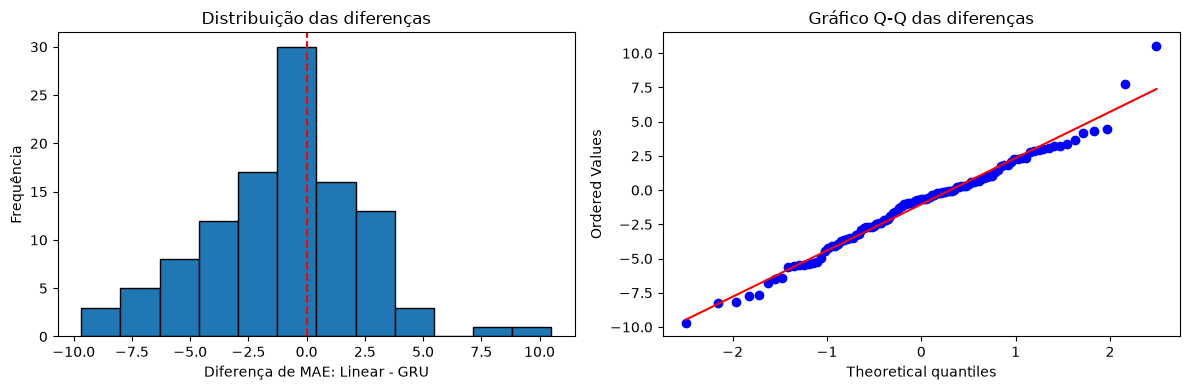

In [69]:
import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].hist(
    diferencas_mae,
    bins="auto",
    edgecolor="black"
)

axes[0].axvline(
    0,
    color="red",
    linestyle="--"
)

axes[0].set_xlabel("Diferença de MAE: Linear - GRU")
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição das diferenças")

stats.probplot(
    diferencas_mae,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title("Gráfico Q-Q das diferenças")

plt.tight_layout()
plt.show()

Se houver poucos pares, valores extremos ou forte assimetria, eu priorizaria o Wilcoxon como análise mais conservadora.

### 8.5.1.  Interpretação do Shapiro-Wilk

As hipóteses do teste são:

-H0​: as diferenças seguem aproximadamente uma distribuição normal;
-H1​: as diferenças não seguem uma distribuição normal.

Como:

```python
p-valor = 0,004402
alfa = 0,010000
```

temos:
```python
p-valor < alfa
```

Portanto, rejeitamos H0​ e concluímos que há evidência estatística de que as diferenças:

```python
diferencas_mae = (
    mae_linear_por_origem
    - mae_gru_por_origem
)
```
**não seguem uma distribuição normal.**

A estatística de 0,9619 está relativamente próxima de 1, mas o valor-p mostra que o afastamento da normalidade foi detectável para o tamanho da sua amostra. Não se deve interpretar apenas a estatística isoladamente.

Como a suposição de normalidade das diferenças foi rejeitada, o teste t pareado perde sustentação como teste principal.

#### Qual teste deve ser priorizado?

Como a suposição de normalidade das diferenças foi rejeitada, o teste t pareado perde sustentação como teste principal.

Assim, entre os dois resultados:

```python
Wilcoxon | p = 0,053272
Teste t | p = 0,010458
```

deve-se priorizar o resultado do **Wilcoxon pareado**, porque ele não exige normalidade das diferenças da mesma forma que o teste t pareado.

O teste de **Shapiro-Wilk** aplicado às diferenças pareadas de MAE rejeitou a hipótese de normalidade ao nível de significância de 1% (W=0,9619, p=0,004402). Em razão da violação dessa premissa, adotou-se o teste não paramétrico de Wilcoxon como análise principal. O teste de Wilcoxon não identificou diferença estatisticamente significativa entre os modelos Linear e GRU no horizonte acumulado de 72 horas (W=2134, p=0,053272), considerando α=0,05.

# Z - Salvando os modelos

## 1. O que será salvo

Cada arquivo de checkpoint armazenará:

- tipo do modelo: `Linear` ou `GRU`;
- pesos treinados, por meio do `state_dict`;
- semente utilizada;
- `tau`, isto é, o tamanho da janela temporal;
- média e desvio-padrão calculados no conjunto de treinamento;
- hiperparâmetros da arquitetura;
- histórico das perdas de treinamento e validação;
- data e hora da execução.

Salvar a média, o desvio-padrão e o `tau` é essencial porque as previsões futuras precisam usar exatamente o mesmo pré-processamento empregado no treinamento.


## 2. Imports necessários


In [70]:
from pathlib import Path
from datetime import datetime
import gc
import random

import numpy as np
import pandas as pd
import torch
from torch import nn


## 3. Definição das arquiteturas

A classe da GRU e a função que cria o modelo linear precisam estar disponíveis antes de carregar os checkpoints.

In [71]:
class GRURegressor(nn.Module):
    def __init__(
        self,
        hidden_size=64,
        num_layers=2,
        dropout=0.2
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.output = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Entrada original: (batch_size, tau)
        # Entrada da GRU: (batch_size, tau, 1)
        x = x.unsqueeze(-1)
        output, _ = self.gru(x)
        return self.output(output[:, -1, :])


def criar_modelo_linear(tau):
    return nn.Linear(tau, 1)


def criar_modelo_gru(
    hidden_size=64,
    num_layers=2,
    dropout=0.2
):
    return GRURegressor(
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout
    )


## 4. Criar pasta e identificação temporal da execução

Gere uma única identificação temporal para toda a rodada de treinamento. Assim, os modelos das diferentes sementes permanecem associados à mesma execução experimental.


In [72]:
# criar pasta se ela não existir
PASTA_MODELOS = Path("modelos_salvos")

if not PASTA_MODELOS.exists():
    PASTA_MODELOS.mkdir(
        parents=True,
        exist_ok=True
    )

In [73]:
data_hora_execucao = datetime.now().strftime(
    "%Y-%m-%d_%H-%M-%S"
)

ID_EXECUCAO = datetime.now().strftime(
    "%Y-%m-%d_%H-%M-%S"
)

print("Identificação da execução:", ID_EXECUCAO)

Identificação da execução: 2026-09-17_20-41-56


## 5. Função para salvar um checkpoint

In [74]:
def salvar_checkpoint(
    modelo,
    nome_modelo,
    semente,
    tau,
    media_treino,
    desvio_treino,
    id_execucao,
    pasta_modelos,
    hiperparametros=None,
    historico=None,
    metadados_adicionais=None
):
    pasta_modelos = Path(pasta_modelos)
    pasta_modelos.mkdir(parents=True, exist_ok=True)

    nome_arquivo = (
        f"{nome_modelo.lower()}_"
        f"semente-{int(semente)}_"
        f"{id_execucao}.pth"
    )

    caminho = pasta_modelos / nome_arquivo

    checkpoint = {
        "versao_checkpoint": 1,
        "nome_modelo": str(nome_modelo),
        "semente": int(semente),
        "tau": int(tau),
        "media_treino": float(media_treino),
        "desvio_treino": float(desvio_treino),
        "id_execucao": str(id_execucao),
        "hiperparametros": hiperparametros or {},
        "historico": historico,
        "metadados_adicionais": metadados_adicionais or {},
        "model_state_dict": {
            nome: tensor.detach().cpu()
            for nome, tensor in modelo.state_dict().items()
        }
    }

    torch.save(checkpoint, caminho)

    print(f"Checkpoint salvo: {caminho}")
    return caminho


In [75]:
hiperparametros_linear = {
    "arquitetura": "nn.Linear",
    "entrada": tau,
    "saida": 1,
    "lr": 0.001,
    "max_epocas": 200,
    "paciencia": 20,
    "batch_size": 32
}

hiperparametros_gru = {
    "arquitetura": "GRURegressor",
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.2,
    "saida": 1,
    "lr": 0.001,
    "max_epocas": 200,
    "paciencia": 20,
    "batch_size": 32
}

metadados_experimento = {
    "fim_treino": int(fim_treino),
    "fim_validacao": int(fim_validacao),
    "tamanho_total": int(len(serie)),
    "coluna_alvo": COLUNA_ALVO,
    "proporcao_treino": 0.70,
    "proporcao_validacao": 0.15,
    "proporcao_teste": 0.15
}


Para uma rastreabilidade ainda maior, registre no checkpoint:

- nome e hash do CSV;
- versão do Python;
- versão do PyTorch;
- versão do NumPy;
- dispositivo usado no treinamento;
- commit do Git correspondente ao código.

In [76]:
import hashlib
import platform


def calcular_sha256(caminho, tamanho_bloco=1024 * 1024):
    sha256 = hashlib.sha256()

    with open(caminho, "rb") as arquivo_aberto:
        while True:
            bloco = arquivo_aberto.read(tamanho_bloco)

            if not bloco:
                break

            sha256.update(bloco)

    return sha256.hexdigest()


metadados_experimento.update({
    "arquivo_csv": str(arquivo),
    "sha256_csv": calcular_sha256(arquivo),
    "python": platform.python_version(),
    "pytorch": torch.__version__,
    "numpy": np.__version__,
    "dispositivo_treinamento": str(device)
})

## 7. Salvar todos os modelos treinados

Este bloco pressupõe a existência das estruturas:

```python
modelos_treinados = {
    "Linear": [modelo_semente_10, ..., modelo_semente_50],
    "GRU": [modelo_semente_10, ..., modelo_semente_50]
}

historicos = {
    "Linear": [historico_10, ..., historico_50],
    "GRU": [historico_10, ..., historico_50]
}

SEMENTES = [10, 20, 30, 40, 50]


In [77]:
caminhos_modelos = {
    "Linear": [],
    "GRU": []
}

for nome_modelo in ["Linear", "GRU"]:
    for indice, modelo in enumerate(
        modelos_treinados[nome_modelo]
    ):
        semente = SEMENTES[indice]

        if nome_modelo == "Linear":
            hiperparametros = hiperparametros_linear
        else:
            hiperparametros = hiperparametros_gru

        caminho = salvar_checkpoint(
            modelo=modelo,
            nome_modelo=nome_modelo,
            semente=semente,
            tau=tau,
            media_treino=media_treino,
            desvio_treino=desvio_treino,
            id_execucao=ID_EXECUCAO,
            pasta_modelos=PASTA_MODELOS,
            hiperparametros=hiperparametros,
            historico=historicos[nome_modelo][indice],
            metadados_adicionais=metadados_experimento
        )

        caminhos_modelos[nome_modelo].append(caminho)


Checkpoint salvo: modelos_salvos\linear_semente-10_2026-09-17_20-41-56.pth
Checkpoint salvo: modelos_salvos\linear_semente-20_2026-09-17_20-41-56.pth
Checkpoint salvo: modelos_salvos\linear_semente-30_2026-09-17_20-41-56.pth
Checkpoint salvo: modelos_salvos\linear_semente-40_2026-09-17_20-41-56.pth
Checkpoint salvo: modelos_salvos\linear_semente-50_2026-09-17_20-41-56.pth
Checkpoint salvo: modelos_salvos\gru_semente-10_2026-09-17_20-41-56.pth
Checkpoint salvo: modelos_salvos\gru_semente-20_2026-09-17_20-41-56.pth
Checkpoint salvo: modelos_salvos\gru_semente-30_2026-09-17_20-41-56.pth
Checkpoint salvo: modelos_salvos\gru_semente-40_2026-09-17_20-41-56.pth
Checkpoint salvo: modelos_salvos\gru_semente-50_2026-09-17_20-41-56.pth


## 8. Verificar se os arquivos foram gravados

In [78]:
for nome_modelo, caminhos in caminhos_modelos.items():
    print(f"\n{nome_modelo}:")

    for caminho in caminhos:
        assert caminho.exists(), (
            f"Arquivo não encontrado: {caminho}"
        )

        tamanho_mb = caminho.stat().st_size / 1024**2

        print(
            f"{caminho.name} | "
            f"{tamanho_mb:.3f} MB"
        )



Linear:
linear_semente-10_2026-09-17_20-41-56.pth | 0.005 MB
linear_semente-20_2026-09-17_20-41-56.pth | 0.005 MB
linear_semente-30_2026-09-17_20-41-56.pth | 0.005 MB
linear_semente-40_2026-09-17_20-41-56.pth | 0.004 MB
linear_semente-50_2026-09-17_20-41-56.pth | 0.005 MB

GRU:
gru_semente-10_2026-09-17_20-41-56.pth | 0.577 MB
gru_semente-20_2026-09-17_20-41-56.pth | 0.577 MB
gru_semente-30_2026-09-17_20-41-56.pth | 0.577 MB
gru_semente-40_2026-09-17_20-41-56.pth | 0.577 MB
gru_semente-50_2026-09-17_20-41-56.pth | 0.577 MB


## 9. Liberar a memória da GPU

In [79]:
# Move os modelos para a CPU antes de apagar as referências.
for nome_modelo in modelos_treinados:
    for modelo in modelos_treinados[nome_modelo]:
        modelo.to("cpu")

# Remove as referências mantidas pelo dicionário.
modelos_treinados.clear()
del modelos_treinados

# Remove possíveis referências temporárias.
for nome_variavel in [
    "modelo",
    "modelo_linear",
    "modelo_gru"
]:
    if nome_variavel in globals():
        del globals()[nome_variavel]

# Executa a coleta de lixo e libera o cache CUDA desocupado.
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

    print(
        "Memória CUDA alocada: "
        f"{torch.cuda.memory_allocated() / 1024**2:.2f} MB"
    )

    print(
        "Memória CUDA reservada: "
        f"{torch.cuda.memory_reserved() / 1024**2:.2f} MB"
    )


Memória CUDA alocada: 16.93 MB
Memória CUDA reservada: 22.00 MB


## 10. Função para carregar um checkpoint

In [ ]:
def carregar_checkpoint(
    caminho,
    dispositivo=None
):
    caminho = Path(caminho)

    if not caminho.exists():
        raise FileNotFoundError(
            f"Checkpoint não encontrado: {caminho}"
        )

    if dispositivo is None:
        dispositivo = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )
    else:
        dispositivo = torch.device(dispositivo)

    # map_location="cpu" evita ocupar a GPU durante a leitura.
    print(f"Carregando checkpoint: {caminho} para {dispositivo}")
    
    checkpoint = torch.load(
        caminho,
        map_location="cpu",
        weights_only=False
    )

    nome_modelo = checkpoint["nome_modelo"]
    tau_checkpoint = int(checkpoint["tau"])
    hiperparametros = checkpoint.get(
        "hiperparametros",
        {}
    )

    if nome_modelo == "Linear":
        modelo = criar_modelo_linear(
            tau=tau_checkpoint
        )

    elif nome_modelo == "GRU":
        modelo = criar_modelo_gru(
            hidden_size=hiperparametros.get(
                "hidden_size",
                64
            ),
            num_layers=hiperparametros.get(
                "num_layers",
                2
            ),
            dropout=hiperparametros.get(
                "dropout",
                0.2
            )
        )

    else:
        raise ValueError(
            f"Tipo de modelo desconhecido: {nome_modelo}"
        )

    modelo.load_state_dict(
        checkpoint["model_state_dict"]
    )

    modelo = modelo.to(dispositivo)
    modelo.eval()

    metadados = {
        chave: valor
        for chave, valor in checkpoint.items()
        if chave != "model_state_dict"
    }

    historico = checkpoint.get("historico", None)

    print(
        f"Modelo carregado: {nome_modelo} | "
        f"semente: {checkpoint['semente']} | "
        f"execução: {checkpoint['id_execucao']} | "
        f"dispositivo: {dispositivo}"
    )

    return modelo, metadados, historico

In [ ]:
# Definindo o dispositivo como CPU para evitar uso de GPU

device = torch.device("cpu")

In [ ]:
# Carregando um modelo Linear previamente treinado

caminho_linear = (
    PASTA_MODELOS
    / "linear_semente-10_2026-09-14_15-35-55.pth"
)

modelo_linear, meta_linear, historico_linear = carregar_checkpoint(
    caminho=caminho_linear,
    dispositivo="cpu"
)




In [ ]:
# Carregando um modelo GRU previamente treinado

caminho_gru = (
    PASTA_MODELOS
    / "gru_semente-10_2026-09-14_15-20-35.pth"
)

modelo_gru, meta_gru, historico_gru = carregar_checkpoint(
    caminho=caminho_gru,
    dispositivo="cpu"
)


In [74]:
print("Linear em modo de treino?", modelo_linear.training)
print("GRU em modo de treino?", modelo_gru.training)


NameError: name 'modelo_linear' is not defined

In [ ]:
def localizar_checkpoint_mais_recente(
    pasta,
    nome_modelo,
    semente=None
):
    pasta = Path(pasta)

    if semente is None:
        padrao = f"{nome_modelo.lower()}_semente-*_*.pth"
    else:
        padrao = (
            f"{nome_modelo.lower()}_"
            f"semente-{int(semente)}_*.pth"
        )

    arquivos = list(pasta.glob(padrao))

    if not arquivos:
        raise FileNotFoundError(
            f"Nenhum checkpoint corresponde a: {padrao}"
        )

    return max(
        arquivos,
        key=lambda arquivo: arquivo.stat().st_mtime
    )


In [ ]:
caminho_linear = localizar_checkpoint_mais_recente(
    pasta=PASTA_MODELOS,
    nome_modelo="Linear",
    semente=10
)

caminho_gru = localizar_checkpoint_mais_recente(
    pasta=PASTA_MODELOS,
    nome_modelo="GRU",
    semente=10
)

modelo_linear, meta_linear, historico_linear = carregar_checkpoint(
    caminho_linear,
    dispositivo="cpu"
)

modelo_gru, meta_gru, historico_gru = carregar_checkpoint(
    caminho_gru,
    dispositivo="cpu"
)


In [ ]:
tau_linear = int(meta_linear["tau"])
media_linear = float(meta_linear["media_treino"])
desvio_linear = float(meta_linear["desvio_treino"])

serie_normalizada_linear = (
    (serie - media_linear) / desvio_linear
).astype(np.float32)


In [ ]:
tau_gru = int(meta_gru["tau"])
media_gru = float(meta_gru["media_treino"])
desvio_gru = float(meta_gru["desvio_treino"])

serie_normalizada_gru = (
    (serie - media_gru) / desvio_gru
).astype(np.float32)


In [ ]:
assert tau_linear == tau_gru, (
    "Os modelos foram treinados com valores de tau diferentes."
)

assert np.isclose(media_linear, media_gru), (
    "As médias de treinamento não coincidem."
)

assert np.isclose(desvio_linear, desvio_gru), (
    "Os desvios-padrão de treinamento não coincidem."
)


Pronto para previsão e avaliação.